## İmport Libraries

In [172]:

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Model selection
from sklearn.model_selection import (train_test_split, StratifiedKFold, 
                                      cross_val_score, cross_val_predict)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, precision_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, PrecisionRecallDisplay,
                              precision_recall_curve)

# Imbalanced learning
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Hyperparameter tuning
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Model saving
import joblib

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


## Loading Dataframe

In [173]:
df=pd.read_csv(r'C:\Users\HP\OneDrive\İş masası\DİV\cell2celltrain.csv') #loading dataframe
df

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51042,3399958,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,6,No,0,60,No,1-Highest,Suburban,Other,Yes
51043,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,...,0,9,No,1,60,No,3-Good,Other,Other,No
51044,3399978,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,7,No,1,80,No,5-Low,Other,Clerical,No
51045,3399990,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,9,No,0,30,No,5-Low,Other,Other,No


## EDA

In [174]:
# Creating a copy of the original dataframe to preserve raw data during preprocessing
df_copy=df.copy() 

In [175]:
#Looking size of dataframe
df.shape 

(51047, 58)

In [176]:
#Realize dataframe
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [177]:
#Looking math functions
df.describe()

,CustomerID,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
count,5.104700e+04,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50680.000000,50680.000000,51047.000000,...,51046.000000,51046.000000,51046.000000,50138.000000,50138.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,3.201957e+06,58.834492,525.653416,46.830088,0.895229,40.027785,1.236244,-11.547908,-1.191985,6.011489,...,1.805646,1.558751,380.545841,31.338127,21.144142,0.037201,0.018277,0.052070,4.324524,0.053911
std,1.169056e+05,44.507336,529.871063,23.848871,2.228546,96.588076,9.818294,257.514772,39.574915,9.043955,...,1.331173,0.905932,253.801982,22.094635,23.931368,0.206483,0.142458,0.307592,3.138236,0.383147
min,3.000002e+06,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,...,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.100632e+06,33.610000,158.000000,30.000000,0.000000,0.000000,0.000000,-83.000000,-7.100000,0.700000,...,1.000000,1.000000,205.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.201534e+06,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-5.000000,-0.300000,3.000000,...,1.000000,1.000000,329.000000,36.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
75%,3.305376e+06,71.065000,723.000000,60.000000,0.990000,41.000000,0.300000,66.000000,1.600000,7.700000,...,2.000000,2.000000,515.000000,48.000000,42.000000,0.000000,0.000000,0.000000,7.000000,0.000000
max,3.399994e+06,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,...,24.000000,15.000000,1812.000000,99.000000,99.000000,4.000000,3.000000,35.000000,9.000000,25.000000


In [178]:
#Print first 5 rows
df.head() 

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [179]:
# Checking target variable distribution to identify class imbalance
target_counts=df["Churn"].value_counts() 
target_counts

Churn
No     36336
Yes    14711
Name: count, dtype: int64

In [180]:
# Normalize=True returns proportions instead of counts
target_pct=df["Churn"].value_counts(normalize=True)*100 
target_pct

Churn
No     71.18146
Yes    28.81854
Name: proportion, dtype: float64

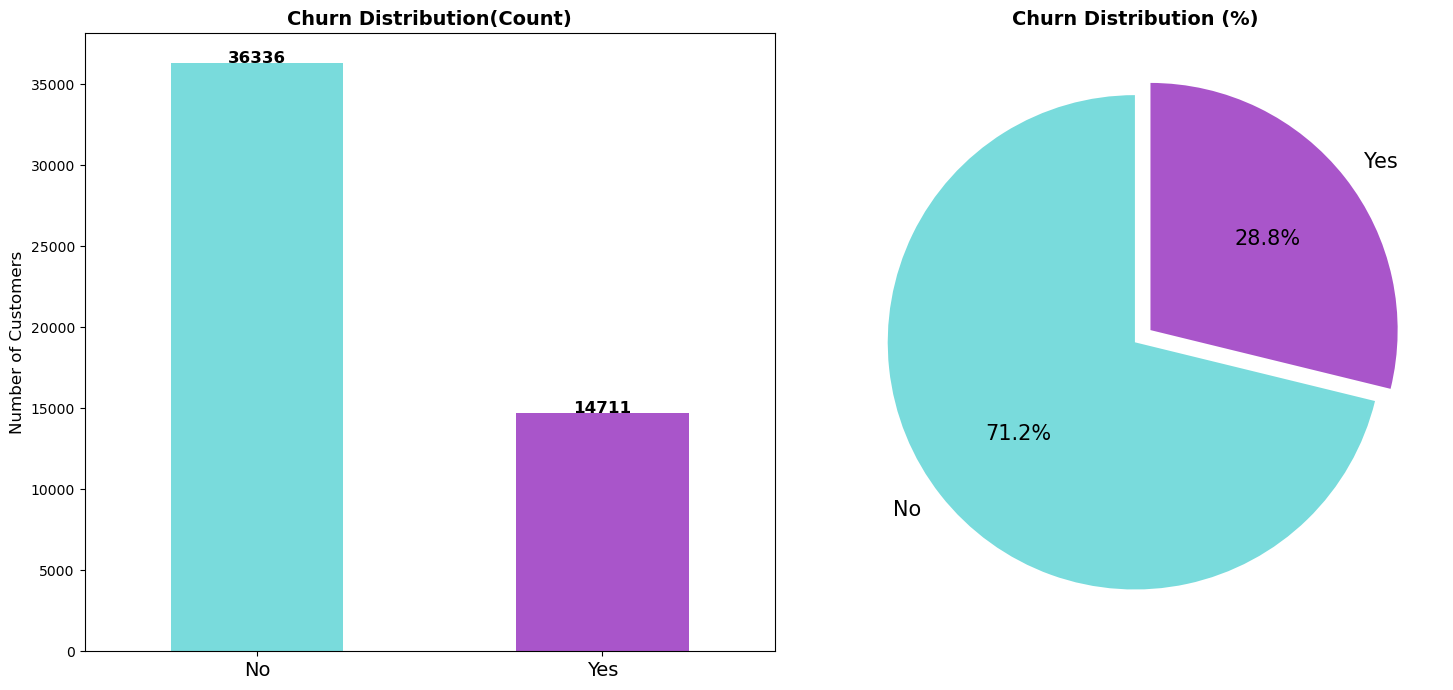

In [181]:
# Visualizing class imbalance using bar chart (absolute counts) 
# and pie chart (percentage distribution)
# Bar chart shows exact customer counts per class
# Pie chart highlights the imbalance ratio between churned and non-churned customers
plt.figure(figsize=(15,7))
colors = ["#79DBDC", "#A955CA"]
#BAR CHART
plt.subplot(1,2,1)
bars=target_counts.plot(kind='bar',color=colors)
plt.title('Churn Distribution(Count)',fontsize=14,fontweight='bold')
plt.xlabel('')
plt.ylabel('Number of Customers',fontsize=12)
plt.xticks(rotation=0,fontsize=14)

for i,value in enumerate(target_counts):
    plt.text(i,value,f"{target_counts[i]}",ha='center',fontsize=12,fontweight='bold')

#PIE CHART
plt.subplot(1,2,2)
target_pct.plot(kind='pie',autopct='%1.1f%%',colors=colors,startangle=90,explode=[0,0.08],
textprops={"fontsize":15})  
plt.title('Churn Distribution (%)',fontsize=14,fontweight='bold')
plt.ylabel('')

plt.tight_layout()

In [182]:
# Converting target variable 'Churn' from categorical (Yes/No) to binary (1/0)
df['Churn']=df['Churn'].map({'Yes':1,'No':0}) 

### Missing Values Analysis

In [183]:
# Calculating missing value counts and percentages for each feature
missing=df.isna().sum()
missing_pct=(df.isna().sum()/len(df))*100

missing_df=pd.DataFrame({
    'Missing Count': missing,
    'Missing PCT': missing_pct
}).sort_values("Missing PCT")

In [184]:
# Filtering to show only columns that contain missing values
missing_df=missing_df[missing_df['Missing Count'] > 0]
missing_df

,Missing Count,Missing PCT
Handsets,1,0.001959
CurrentEquipmentDays,1,0.001959
HandsetModels,1,0.001959
ServiceArea,24,0.047015
RoamingCalls,156,0.305601
OverageMinutes,156,0.305601
DirectorAssistedCalls,156,0.305601
TotalRecurringCharge,156,0.305601
MonthlyMinutes,156,0.305601
MonthlyRevenue,156,0.305601


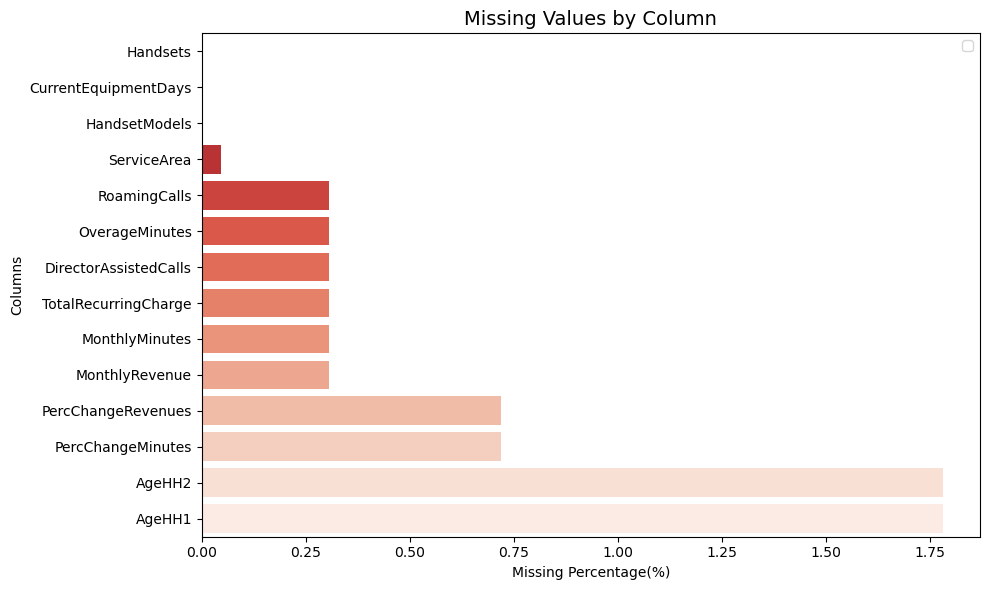

In [185]:
# Visualizing missing value percentages across features using a horizontal bar chart
# Sorted by missing percentage to quickly identify the most affected columns
plt.figure(figsize=(10,6))
sns.barplot(x=missing_df['Missing PCT'],y=missing_df.index,palette='Reds_r')

plt.title('Missing Values by Column',fontsize=14)
plt.xlabel('Missing Percentage(%)')
plt.ylabel('Columns')
plt.legend()
plt.tight_layout()

In [186]:
# Investigating whether missing values carry predictive signal for churn
# Comparing churn rate between rows where value is missing vs not missing
# A significant difference indicates the NaN itself is informative
nan_cols=missing_df.index.tolist()

for col in nan_cols:
    churn_nan=df[df[col].isna()]['Churn'].mean()
    churn_not_nan=df[df[col].notnull()]['Churn'].mean()

    print(f"{col}:")
    print(f"  Churn rate for Nan:     {churn_nan:.3f}")
    print(f"  Churn rate for not Nan:  {churn_not_nan:.3f}")
    print(f"  Difference: {abs(churn_nan - churn_not_nan):.3f}")

Handsets:
  Churn rate for Nan:     0.000
  Churn rate for not Nan:  0.288
  Difference: 0.288
CurrentEquipmentDays:
  Churn rate for Nan:     0.000
  Churn rate for not Nan:  0.288
  Difference: 0.288
HandsetModels:
  Churn rate for Nan:     0.000
  Churn rate for not Nan:  0.288
  Difference: 0.288
ServiceArea:
  Churn rate for Nan:     0.500
  Churn rate for not Nan:  0.288
  Difference: 0.212
RoamingCalls:
  Churn rate for Nan:     0.449
  Churn rate for not Nan:  0.288
  Difference: 0.161
OverageMinutes:
  Churn rate for Nan:     0.449
  Churn rate for not Nan:  0.288
  Difference: 0.161
DirectorAssistedCalls:
  Churn rate for Nan:     0.449
  Churn rate for not Nan:  0.288
  Difference: 0.161
TotalRecurringCharge:
  Churn rate for Nan:     0.449
  Churn rate for not Nan:  0.288
  Difference: 0.161
MonthlyMinutes:
  Churn rate for Nan:     0.449
  Churn rate for not Nan:  0.288
  Difference: 0.161
MonthlyRevenue:
  Churn rate for Nan:     0.449
  Churn rate for not Nan:  0.288
  D

### Constant and Quasi-Constant Feature Check

In [187]:
constant_cols=[col for col in df.columns if df[col].nunique()==1]
print(f'Constant features (1 unique value): {constant_cols}')

Constant features (1 unique value): []


In [188]:
quasi_constant_cols=[]

for col in df.columns:
    if col.endswith('missing'):
        continue
    
    top_freq=df[col].value_counts(normalize=True).values[0]

    if top_freq>0.98 or top_freq==0.98:
        quasi_constant_cols.append(col)

print("Nmber of columns to delete:", len(quasi_constant_cols))
quasi_constant_cols

Nmber of columns to delete: 4


['CallForwardingCalls',
 'OptOutMailings',
 'RetentionOffersAccepted',
 'OwnsMotorcycle']

In [189]:
for col in ['RetentionCalls', 'RetentionOffersAccepted', 'MadeCallToRetentionTeam']:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True) * 100)


RetentionCalls:
RetentionCalls
0    96.581582
1     3.151997
2     0.235077
3     0.027426
4     0.003918
Name: proportion, dtype: float64

RetentionOffersAccepted:
RetentionOffersAccepted
0    98.274140
1     1.639665
2     0.070523
3     0.015672
Name: proportion, dtype: float64

MadeCallToRetentionTeam:
MadeCallToRetentionTeam
No     96.581582
Yes     3.418418
Name: proportion, dtype: float64


## Checking dublicates

In [190]:
n_duplicates=df.duplicated().sum()
print(f'Number of exact duplicate rows: {n_duplicates}')
print(f'Percentage of total rows: {round(n_duplicates / len(df) * 100, 3)}%')

Number of exact duplicate rows: 0
Percentage of total rows: 0.0%


### Correlation-Heatmap

In [191]:
numeric_cols=df.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

Text(0.5, 1.0, 'Correlation Heatmap')

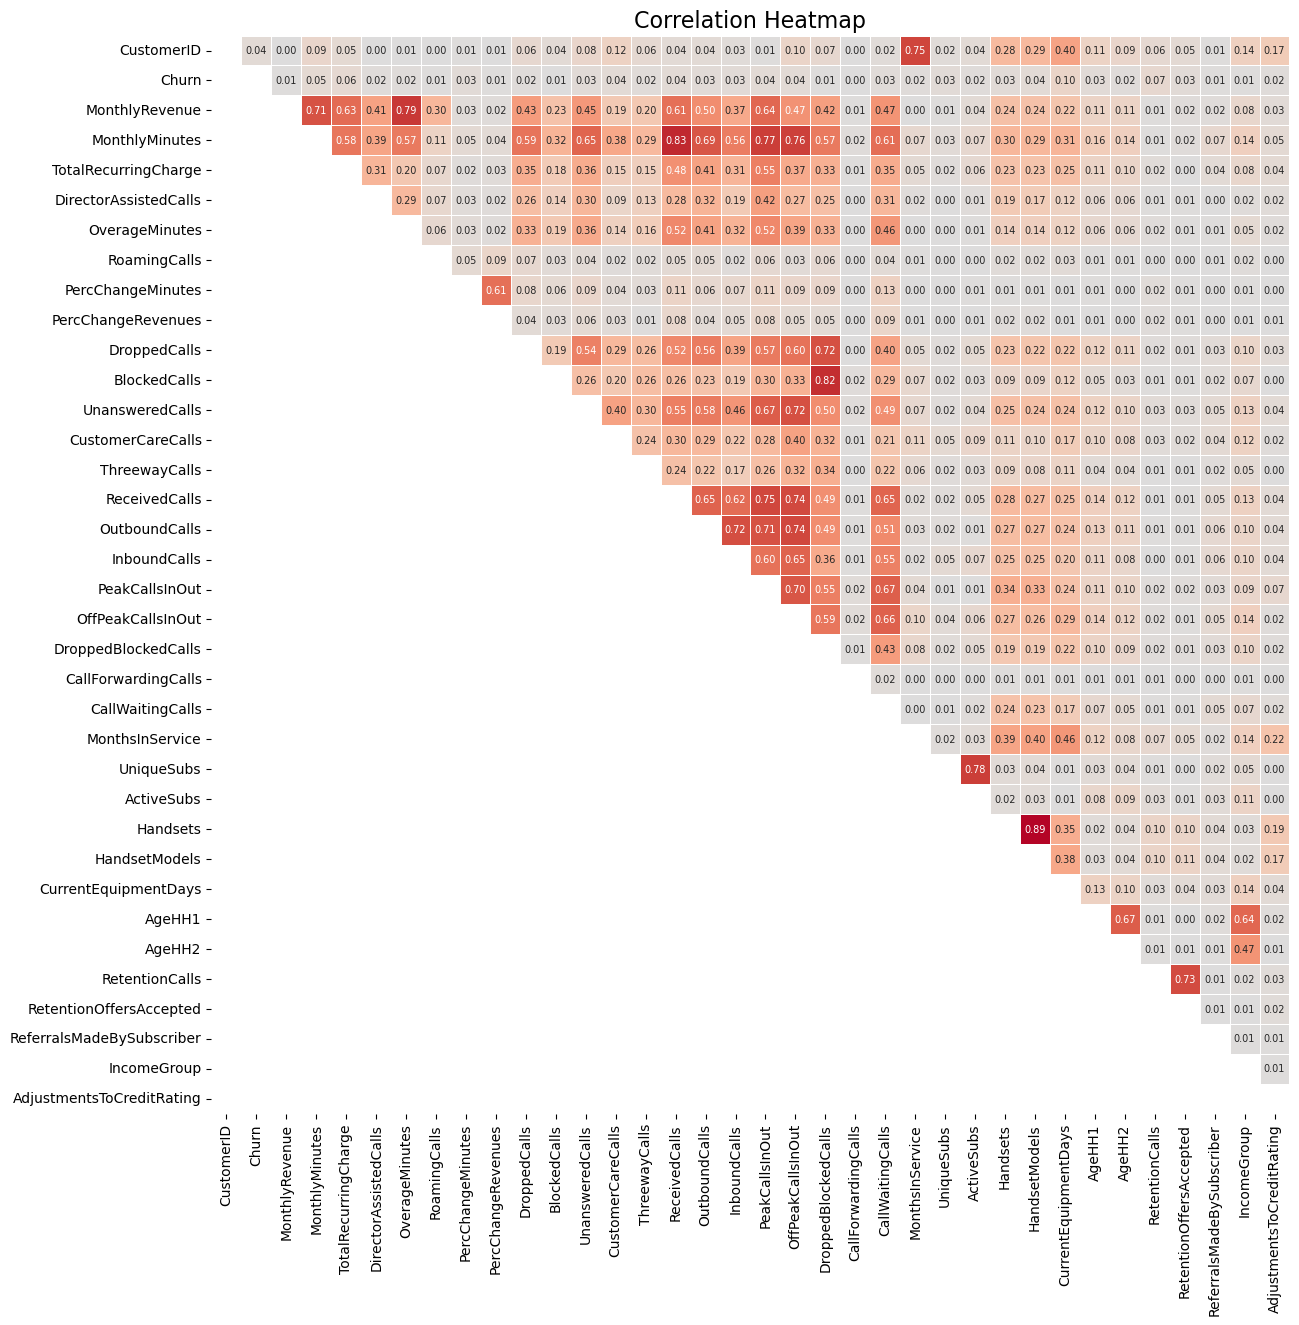

In [196]:
plt.figure(figsize=(18,14))

sns.heatmap(
    upper,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot=True, 
    annot_kws={"size": 7},
    fmt='.2f',
    cbar=False)

plt.title("Correlation Heatmap", fontsize=16)

In [23]:
to_drop = [column for column in upper.columns 
           if any(upper[column].abs() > 0.8)]

print(len(to_drop), ":", to_drop)

3 : ['ReceivedCalls', 'DroppedBlockedCalls', 'HandsetModels']


In [ ]:
# Columns to be deleted
ID_like_columns=df['CustomerID']

Target_columns=df['Churn']

In [25]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols = num_cols.drop(["Churn","CustomerID"])

In [26]:
corr_with_target=df[num_cols].corrwith(df['Churn']).sort_values(ascending=False)
top_features_target=corr_with_target.abs().sort_values(ascending=False).head(10).index
top_features_target

Index(['CurrentEquipmentDays', 'RetentionCalls', 'TotalRecurringCharge',
       'MonthlyMinutes', 'OffPeakCallsInOut', 'HandsetModels',
       'PeakCallsInOut', 'ReceivedCalls', 'CustomerCareCalls',
       'RetentionOffersAccepted'],
      dtype='object')

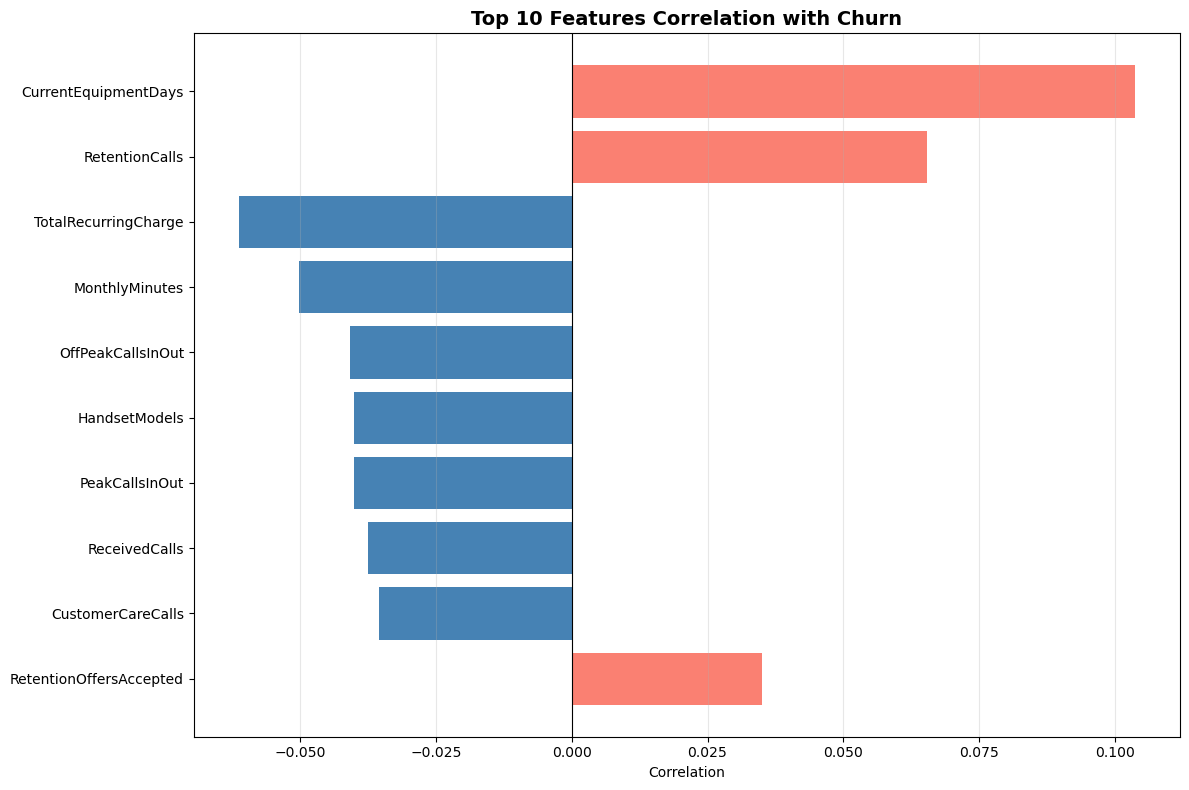

In [27]:
top_corr = corr_with_target[list(top_features_target[:10])]
# No single feature shows strong linear correlation with churn (max: 0.10). 
# This suggests that churn behavior is driven by complex interactions between multiple features
#  rather than any individual variable, making tree-based ensemble models more suitable for this dataset
plt.figure(figsize=(12, 8))
colors = ['salmon' if x > 0 else 'steelblue' for x in top_corr.values]

plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 10 Features Correlation with Churn', fontsize=14, fontweight='bold')
plt.xlabel('Correlation')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
top_corr

CurrentEquipmentDays       0.103688
RetentionCalls             0.065301
TotalRecurringCharge      -0.061296
MonthlyMinutes            -0.050166
OffPeakCallsInOut         -0.040784
HandsetModels             -0.040048
PeakCallsInOut            -0.040029
ReceivedCalls             -0.037453
CustomerCareCalls         -0.035510
RetentionOffersAccepted    0.034953
dtype: float64

### Feature Selection

In [29]:
feature_diff={}

for col in num_cols:
    mean_0=df[df['Churn']==0][col].mean()
    mean_1=df[df['Churn']==1][col].mean()
    std=df[col].std()

    if std>0:
        diff=abs(mean_1-mean_0)/std #normalize
    else:
        diff=0

    feature_diff[col]=diff

feature_diff_df=pd.Series(feature_diff).sort_values(ascending=False)
top_features=feature_diff_df.head(10).index

top_features

Index(['CurrentEquipmentDays', 'RetentionCalls', 'TotalRecurringCharge',
       'MonthlyMinutes', 'OffPeakCallsInOut', 'HandsetModels',
       'PeakCallsInOut', 'ReceivedCalls', 'CustomerCareCalls',
       'RetentionOffersAccepted'],
      dtype='object')

C:\Users\HP\AppData\Local\Temp\ipykernel_14344\3428975837.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


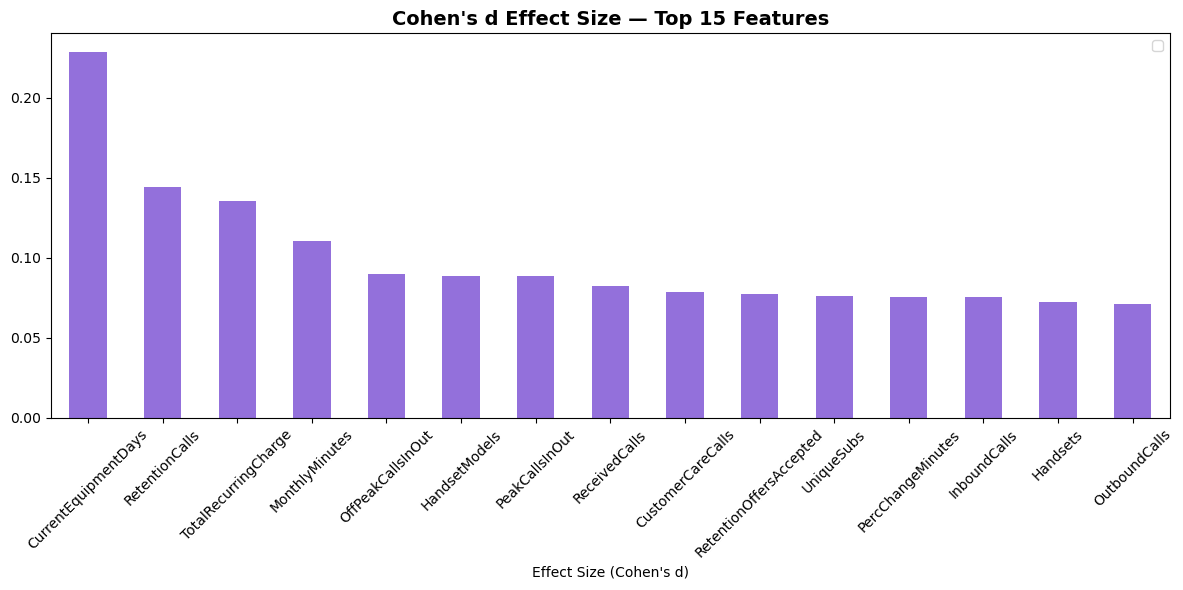

In [30]:
plt.figure(figsize=(12, 6))
feature_diff_df.head(15).plot(kind='bar', color='mediumpurple')
plt.title("Cohen's d Effect Size — Top 15 Features", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel("Effect Size (Cohen's d)")
plt.legend()
plt.tight_layout()
plt.show()

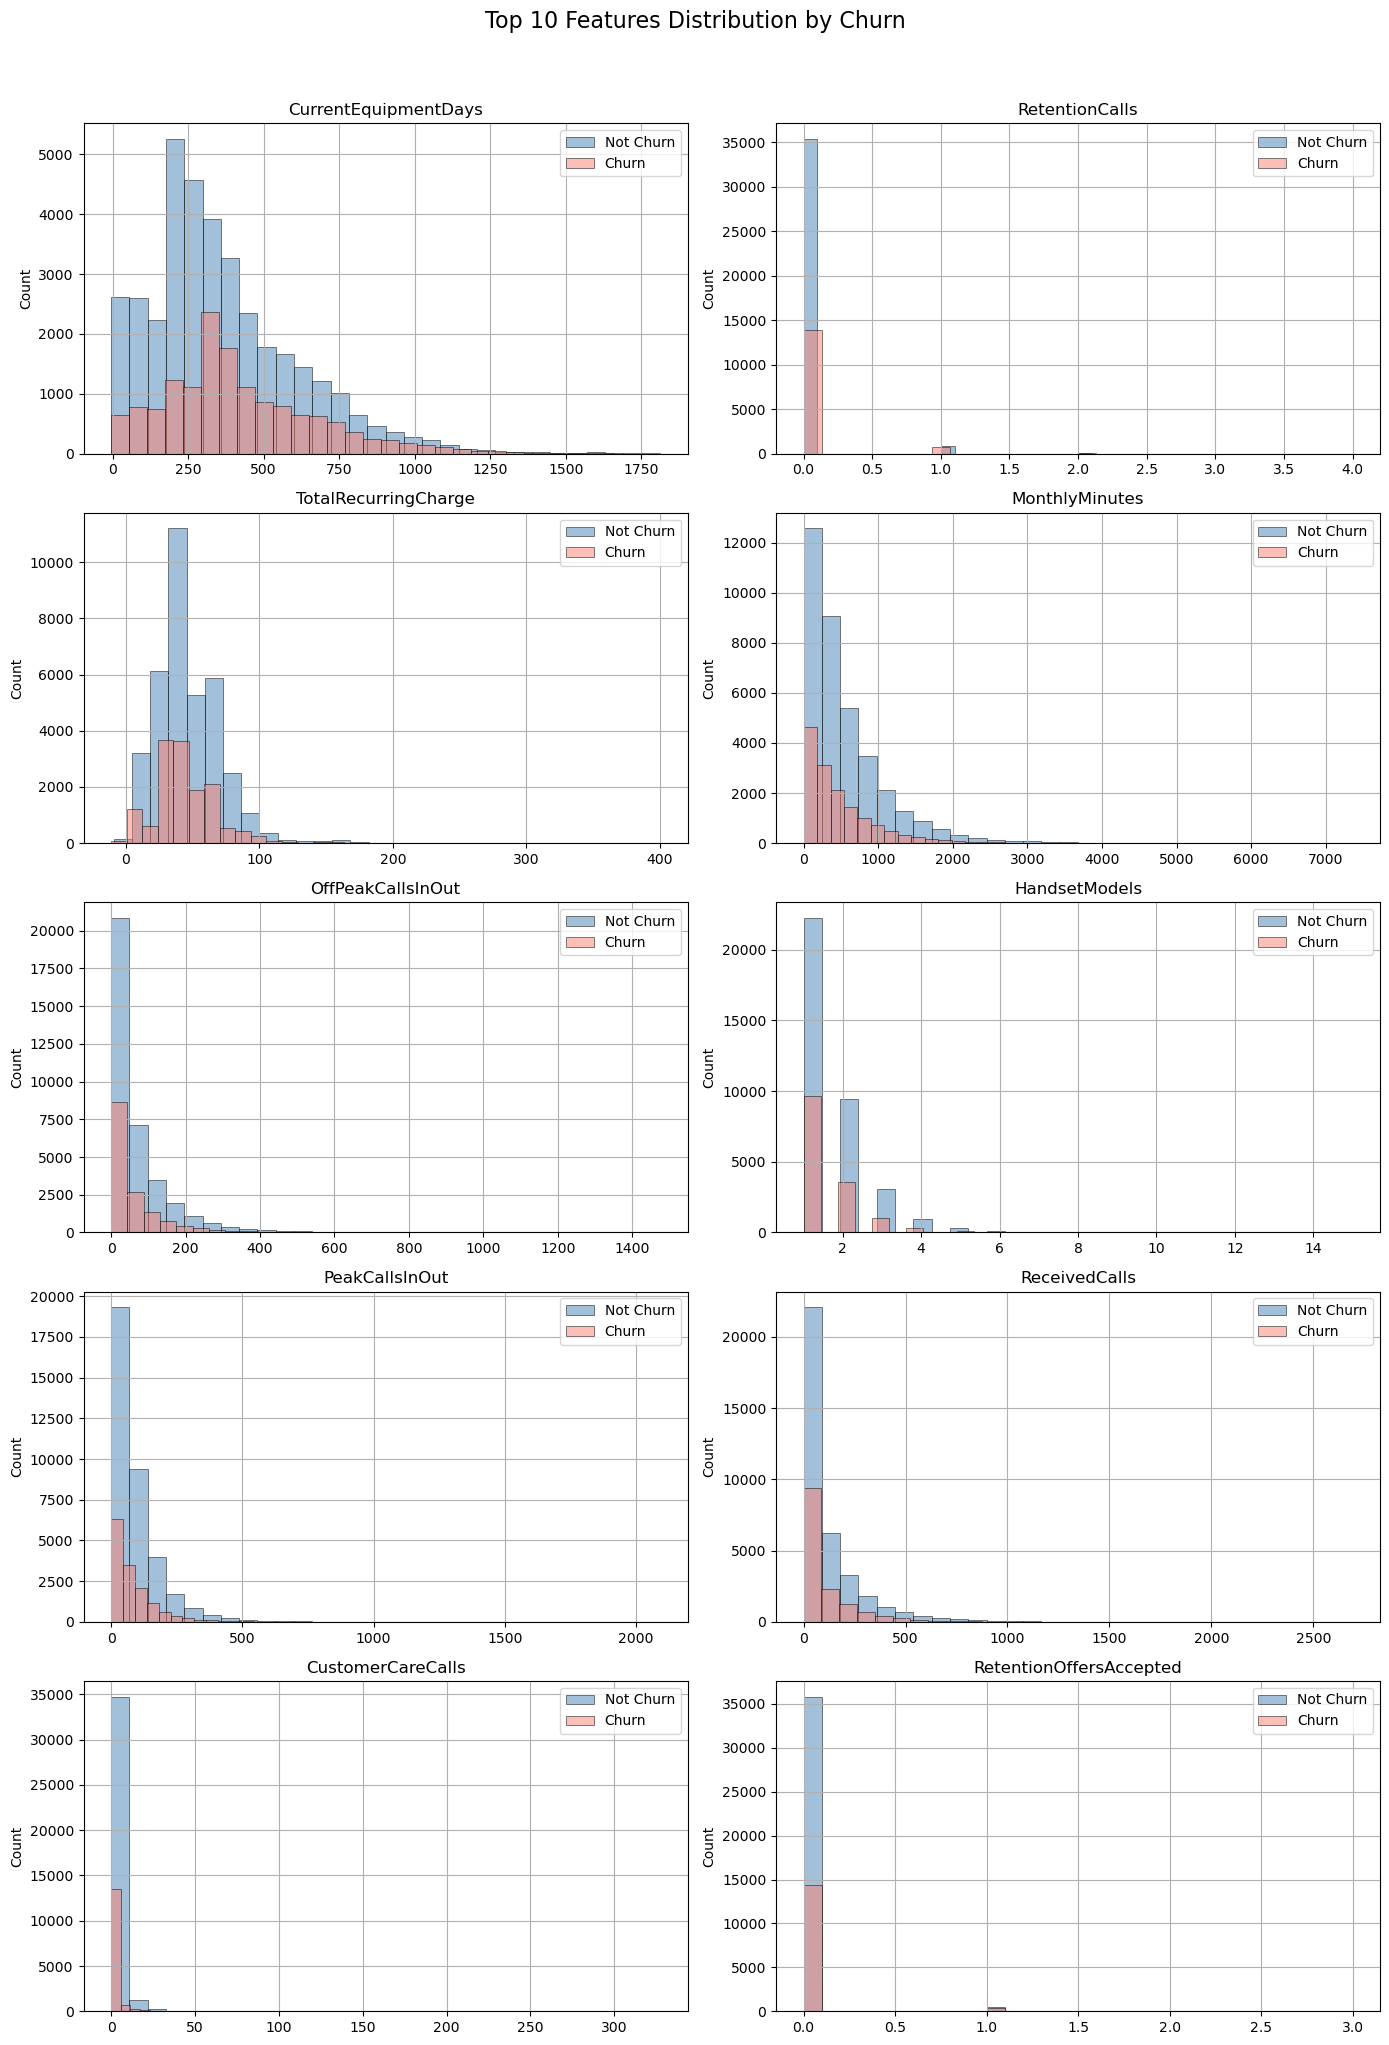

In [31]:
fig,axes=plt.subplots(5,2,figsize=(14,20))
axes=axes.flatten()

for i,col in enumerate(top_features):
    ax=axes[i]
    df[df['Churn']==0][col].hist(ax=ax,alpha=0.5,label='Not Churn',
                                 color='steelblue',bins=30,
                                 edgecolor='black', linewidth=0.7)
    df[df['Churn']==1][col].hist(ax=ax,alpha=0.5,label='Churn',
                                 color='salmon',bins=30,
                                 edgecolor='black', linewidth=0.7)
    ax.set_title(f'{col}')
    ax.set_title(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Top 10 Features Distribution by Churn', fontsize=16, y=1.02)
plt.tight_layout()

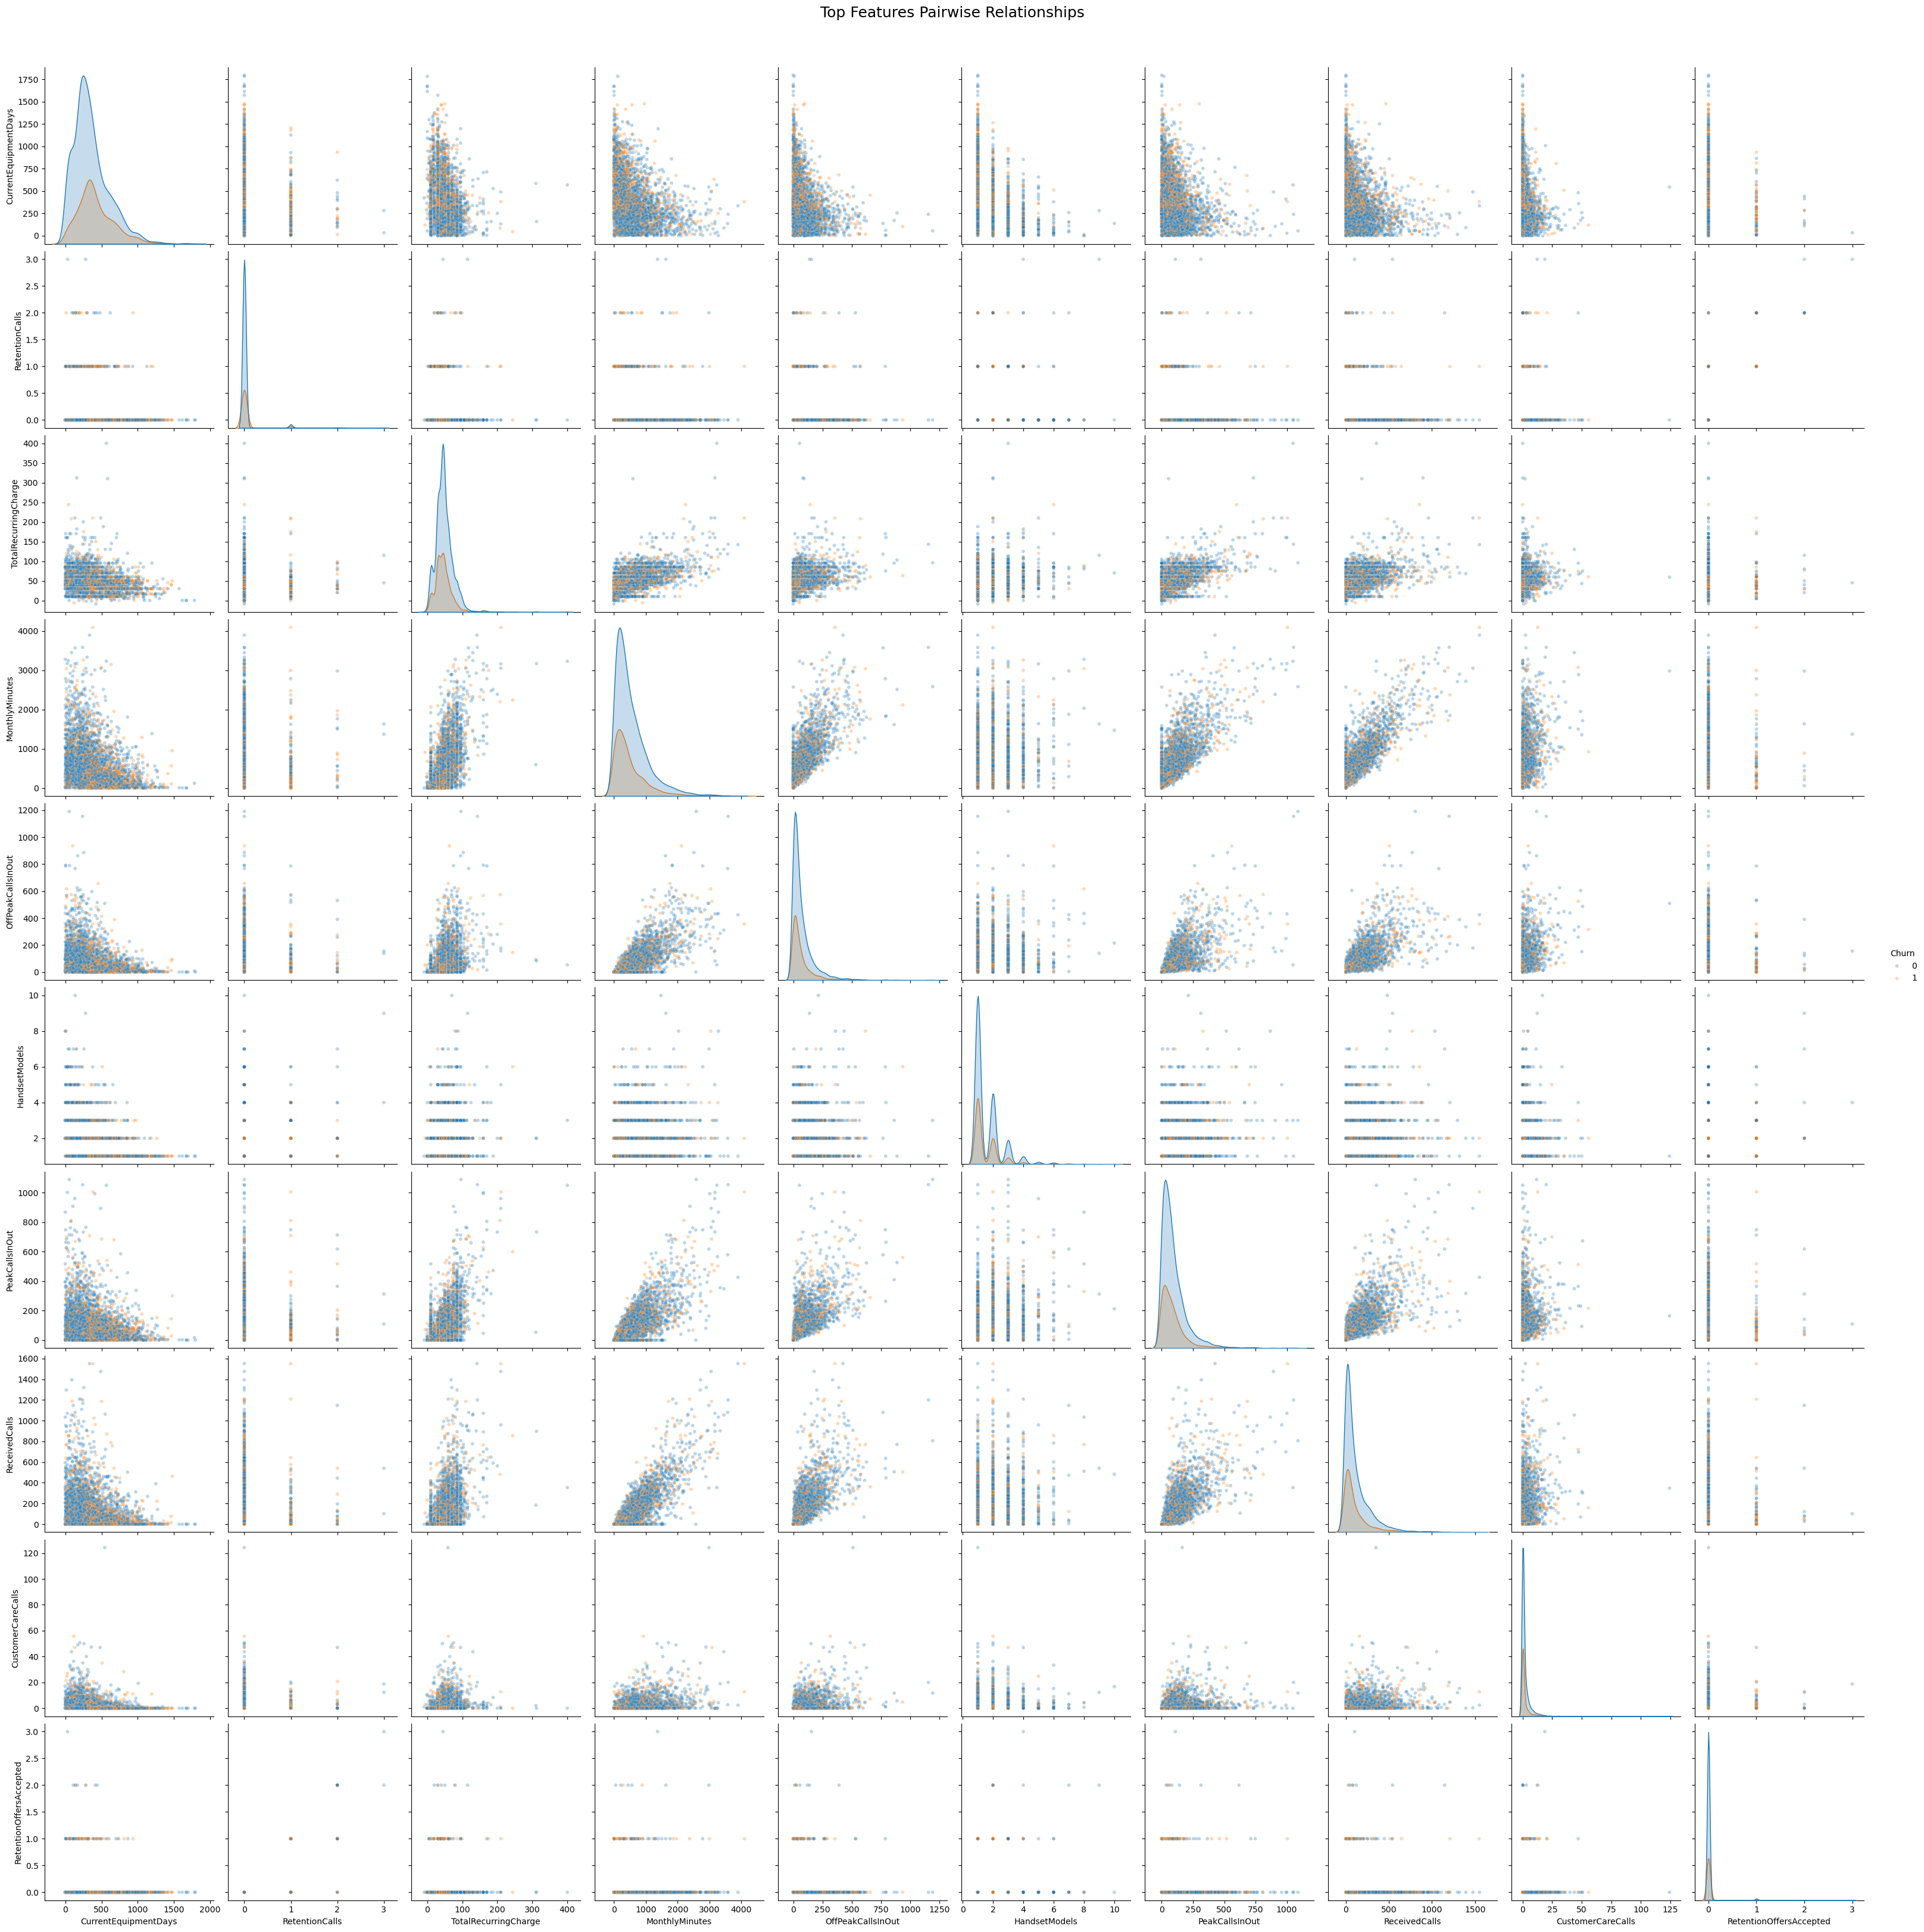

In [32]:
sample_df = df.sample(5000, random_state=42)

sns.pairplot(sample_df[top_features.tolist() + ['Churn']],
             hue='Churn',
             corner=False,
             height=3.2,
             plot_kws={'alpha':0.3, 's':18})

plt.suptitle("Top Features Pairwise Relationships",fontsize=18, y=1.02)
plt.show()  

### Outliers

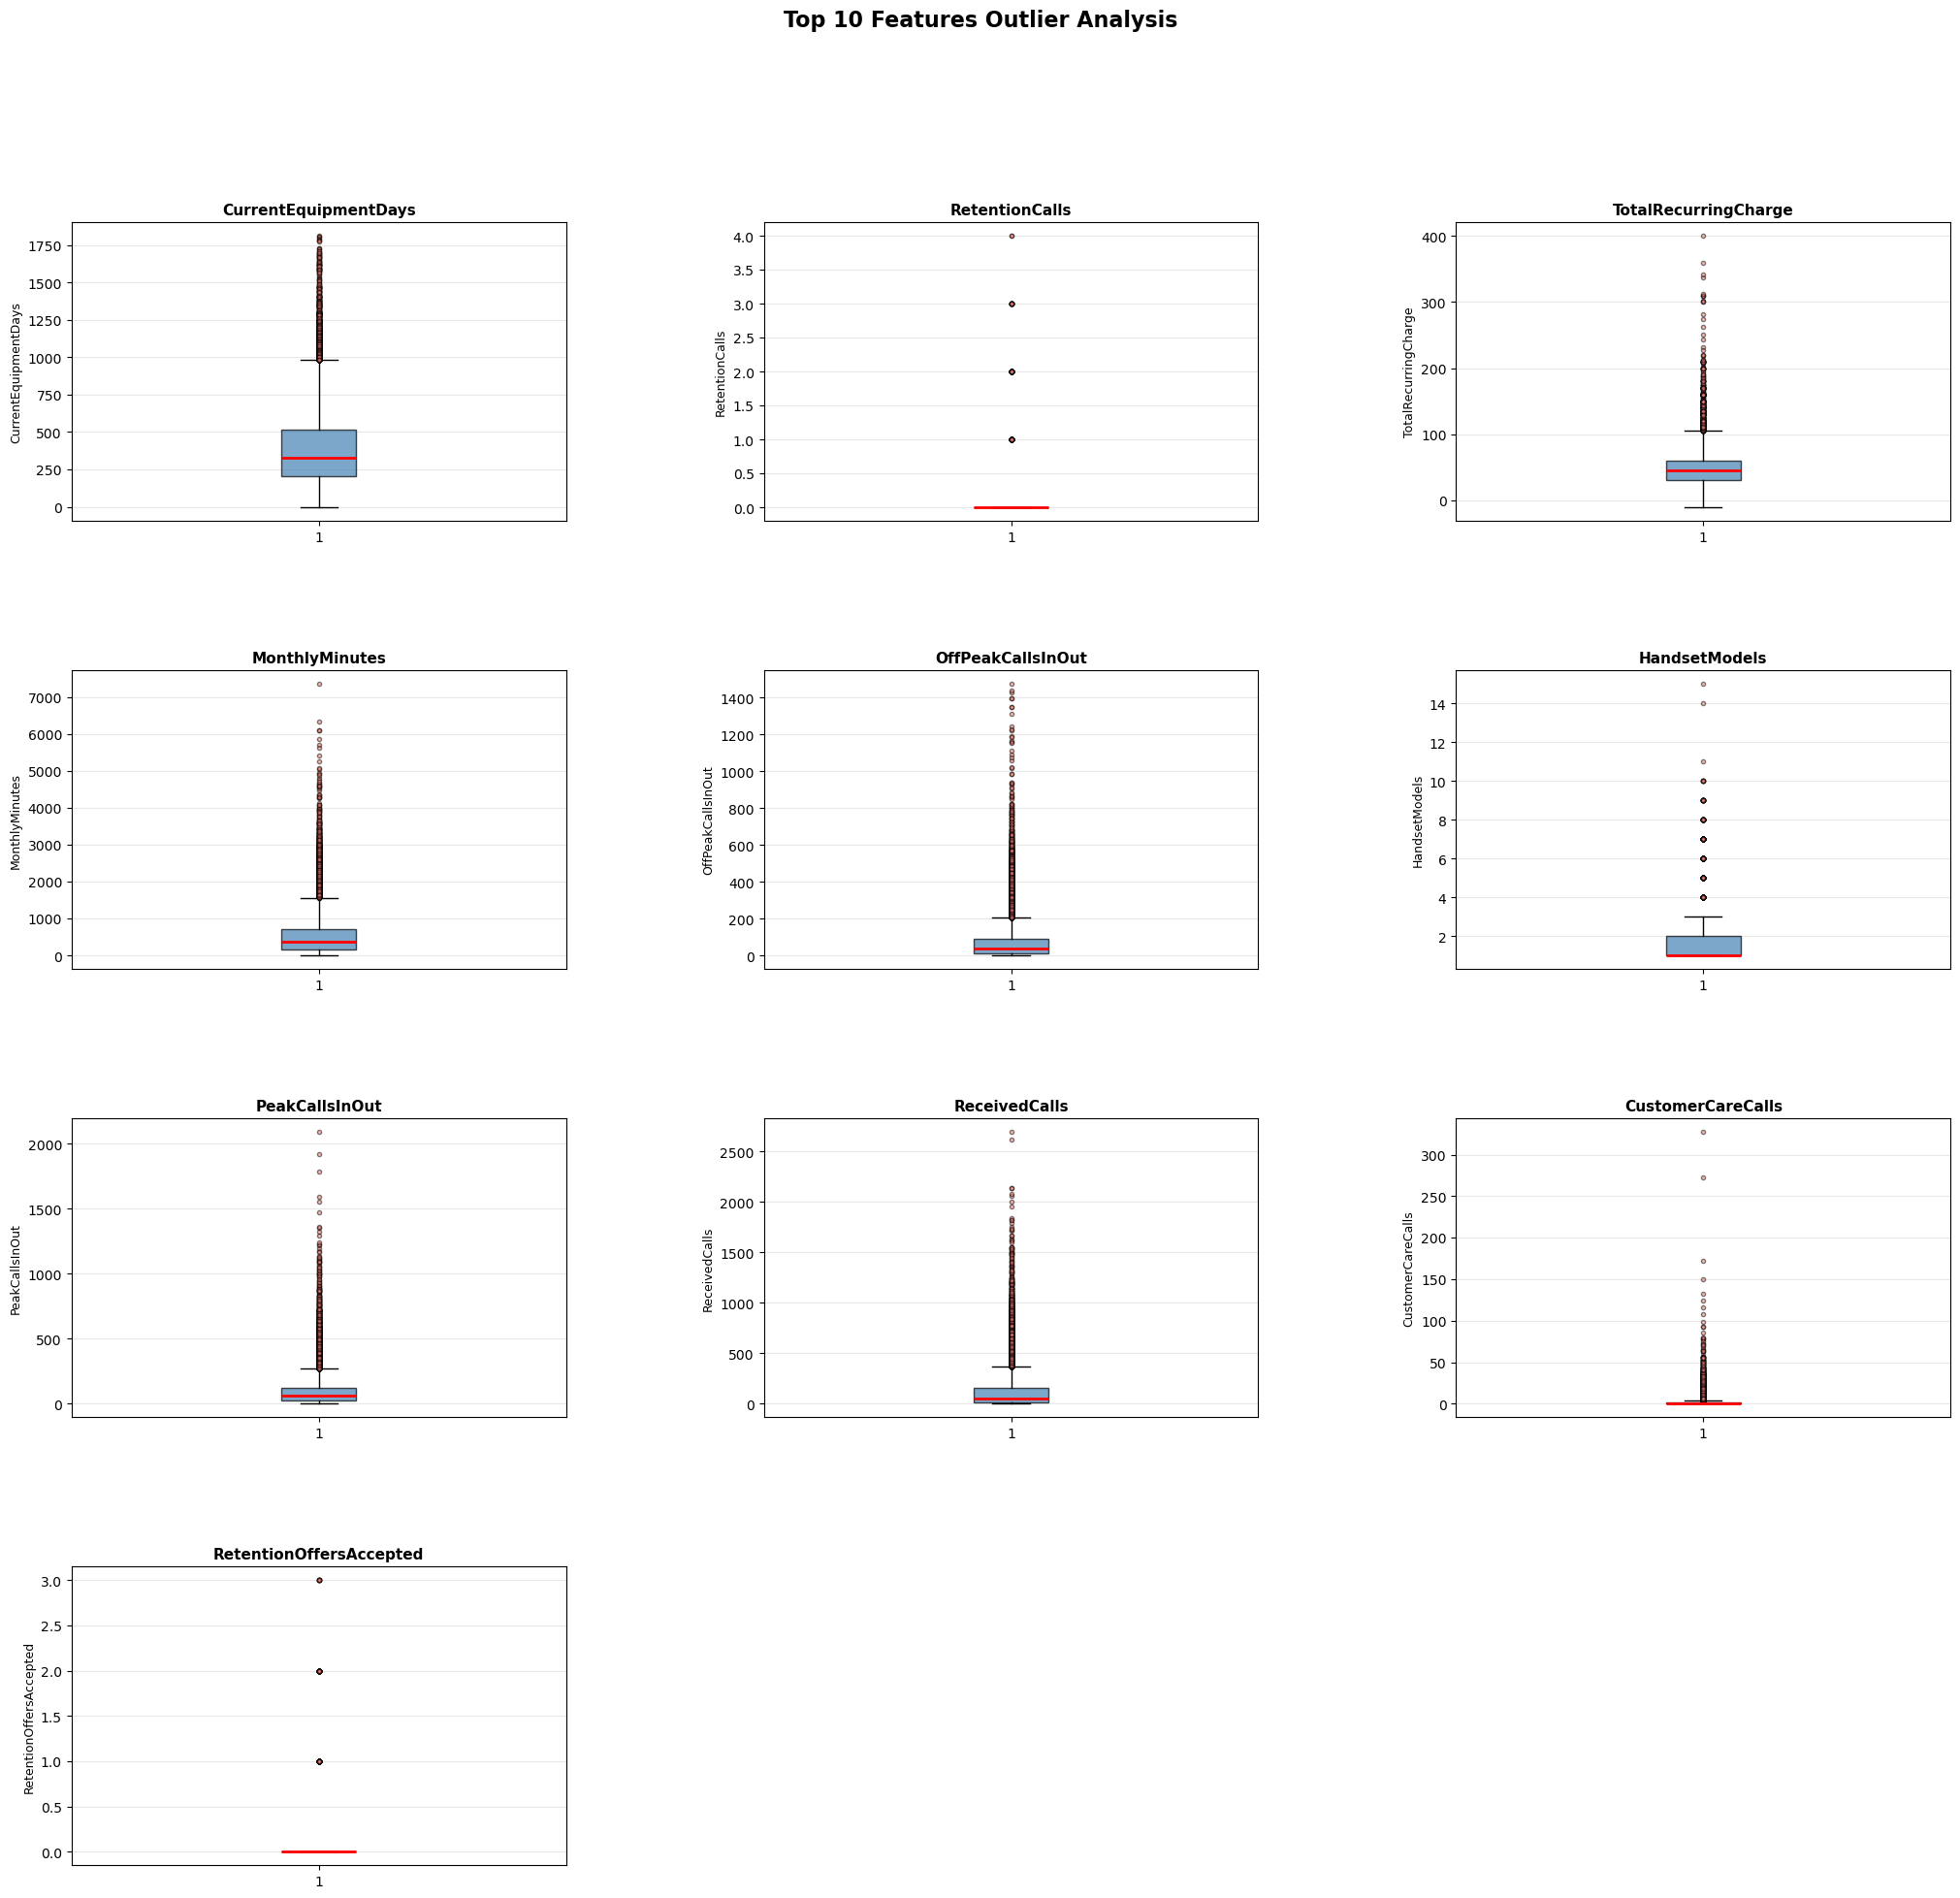

In [33]:
fig,axes=plt.subplots(4,3,figsize=(25,22))
axes=axes.flatten()

for i,col in enumerate(top_features[:10]):
    axes[i].boxplot(df[col].dropna(),
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue',alpha=0.7),
                    medianprops=dict(color='red',linewidth=2),
                    flierprops=dict(marker='o',markerfacecolor='salmon',
                    markersize=3,alpha=0.5))

    axes[i].set_title(col,fontsize=11,fontweight='bold')
    axes[i].set_ylabel(col,fontsize=9)
    axes[i].grid(axis='y',alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 10 Features Outlier Analysis', fontsize=16, fontweight='bold')
plt.subplots_adjust(hspace=0.5, wspace=0.4)


C:\Users\HP\AppData\Local\Temp\ipykernel_14344\2801003237.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([churn_0, churn_1],
C:\Users\HP\AppData\Local\Temp\ipykernel_14344\2801003237.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([churn_0, churn_1],
C:\Users\HP\AppData\Local\Temp\ipykernel_14344\2801003237.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([churn_0, churn_1],
C:\Users\HP\AppData\Local\Temp\ipykernel_14344\2801003237.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matpl

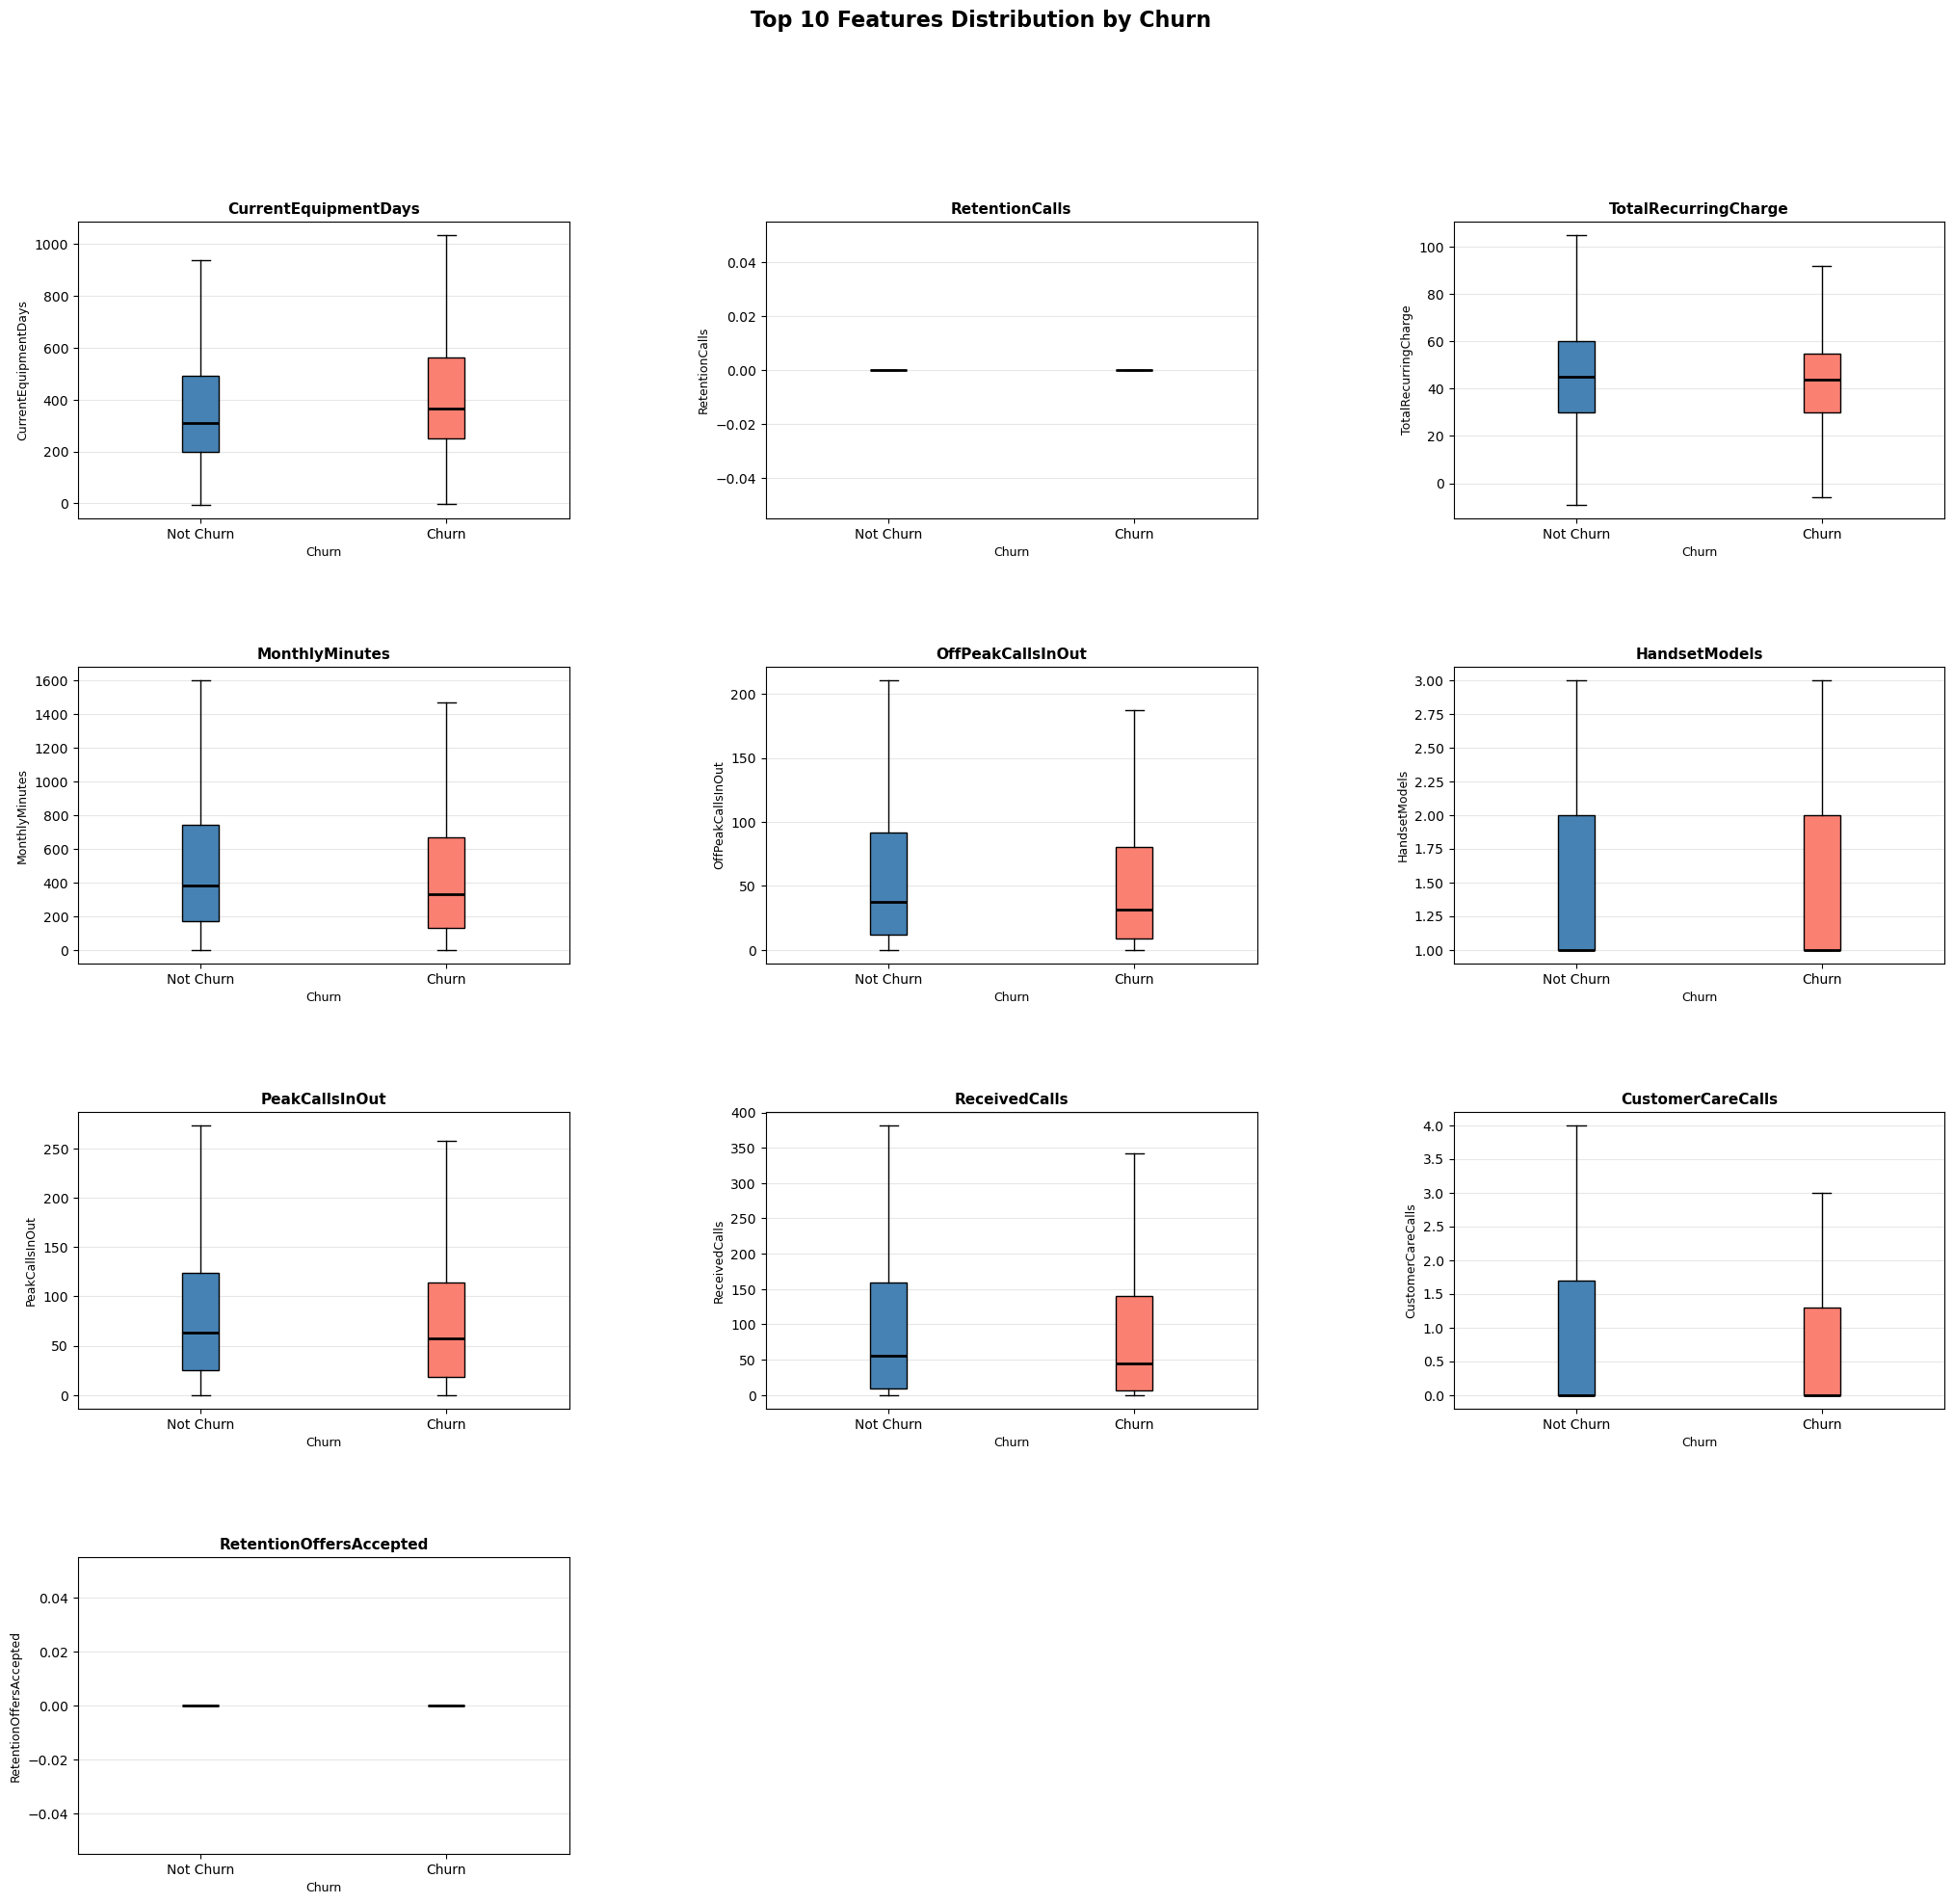

In [34]:
fig, axes = plt.subplots(4, 3, figsize=(25, 22))
axes = axes.flatten()

for i, col in enumerate(top_features[:10]):
    churn_0 = df[df['Churn'] == 0][col].dropna()
    churn_1 = df[df['Churn'] == 1][col].dropna()
    
    bp = axes[i].boxplot([churn_0, churn_1],
                          patch_artist=True,
                          labels=['Not Churn', 'Churn'],
                          showfliers=False) 
    
    # rənglər
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('salmon')
    
    # median xətti
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)
    
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Churn', fontsize=9)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 10 Features Distribution by Churn', fontsize=16, fontweight='bold')
plt.subplots_adjust(hspace=0.5, wspace=0.4)

In [35]:
outliers=[]

for col in num_cols:
    data=df[col].dropna()
    Q1=data.quantile(0.25)
    Q2=data.quantile(0.75)
    IQR=Q2-Q1
    lower=Q1-1.5*IQR
    upper=Q2+1.5*IQR

    n_outliers=((data<lower) | (data>upper)).sum()
    pct_outliers=(n_outliers / len(data))*100

    outliers.append({
        'Feature': col,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': n_outliers,
        'Outlier Pct': round(pct_outliers, 3)
    })

    outlier_df = pd.DataFrame(outliers).set_index('Feature')
print(outlier_df.sort_values('Outlier Pct', ascending=False))

                           Lower Bound  Upper Bound  Outlier Count  \
Feature                                                              
PercChangeRevenues            -20.1500      14.6500          13221   
RoamingCalls                   -0.4500       0.7500           8835   
CallWaitingCalls               -1.9500       3.2500           7448   
PercChangeMinutes            -306.5000     289.5000           6807   
CustomerCareCalls              -2.5500       4.2500           6721   
OverageMinutes                -61.5000     102.5000           5842   
DirectorAssistedCalls          -1.4850       2.4750           5530   
BlockedCalls                   -5.5500       9.2500           5517   
InboundCalls                  -13.9500      23.2500           4973   
ThreewayCalls                  -0.4500       0.7500           4622   
Handsets                       -0.5000       3.5000           4414   
DroppedBlockedCalls           -14.2000      28.2000           3936   
DroppedCalls        

In [36]:
#features=df.drop('Churn',axis = 1)
feature_stats=df.groupby('Churn')[num_cols].agg(['mean','median']).T
pd.set_option('display.max_rows', 100)
feature_stats

Churn                                      0           1
MonthlyRevenue            mean     59.173538   57.995041
                          median   48.815000   47.520000
MonthlyMinutes            mean    542.546483  483.827471
                          median  381.000000  330.000000
TotalRecurringCharge      mean     47.759117   44.529882
                          median   45.000000   44.000000
DirectorAssistedCalls     mean      0.922870    0.826793
                          median    0.250000    0.250000
OverageMinutes            mean     39.017379   42.529472
                          median    2.000000    4.000000
RoamingCalls              mean      1.168345    1.404358
                          median    0.000000    0.000000
PercChangeMinutes         mean     -5.971335  -25.458388
                          median   -3.000000  -11.000000
PercChangeRevenues        mean     -1.470553   -0.497111
                          median   -0.300000   -0.300000
DroppedCalls              mean      6.100094    5.792638
                          median    3.000000    3.000000
BlockedCalls              mean      4.124188    3.990538
                          median    1.000000    1.000000
UnansweredCalls           mean     29.014991   26.495745
                          median   16.700000   14.700000
CustomerCareCalls         mean      1.984142    1.584597
                          median    0.000000    0.000000
ThreewayCalls             mean      0.316570    0.255040
                          median    0.000000    0.000000
ReceivedCalls             mean    118.767558  105.000598
                          median   56.000000   44.900000
OutboundCalls             mean     26.100793   23.591720
                          median   14.000000   12.000000
InboundCalls              mean      8.541111    7.281483
                          median    2.300000    1.700000
PeakCallsInOut            mean     93.222485   83.947312
                          median   63.700000   57.700000
OffPeakCallsInOut         mean     70.057714   61.705717
                          median   37.700000   31.300000
DroppedBlockedCalls       mean     10.289303    9.833696
                          median    5.700000    5.300000
CallForwardingCalls       mean      0.012825    0.010924
                          median    0.000000    0.000000
CallWaitingCalls          mean      1.931666    1.615335
                          median    0.300000    0.000000
MonthsInService           mean     18.639641   19.044321
                          median   16.000000   17.000000
UniqueSubs                mean      1.505284    1.598532
                          median    1.000000    1.000000
ActiveSubs                mean      1.347672    1.370811
                          median    1.000000    1.000000
Handsets                  mean      1.833466    1.736932
                          median    1.000000    1.000000
HandsetModels             mean      1.581836    1.501733
                          median    1.000000    1.000000
CurrentEquipmentDays      mean    363.801156  421.903881
                          median  310.000000  366.000000
AgeHH1                    mean     31.756503   30.306043
                          median   36.000000   34.000000
AgeHH2                    mean     21.427178   20.445927
                          median    0.000000    0.000000
RetentionCalls            mean      0.028622    0.058392
                          median    0.000000    0.000000
RetentionOffersAccepted   mean      0.015109    0.026103
                          median    0.000000    0.000000
ReferralsMadeBySubscriber mean      0.054161    0.046904
                          median    0.000000    0.000000
IncomeGroup               mean      4.349901    4.261845
                          median    5.000000    5.000000
AdjustmentsToCreditRating mean      0.058069    0.043641
                          median    0.000000    0.000000

### Skewness and Kurtosis

In [37]:
from scipy import stats

skewness_df = pd.DataFrame({
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurt()
}).sort_values('Skewness', ascending=False)

skewness_df

,Skewness,Kurtosis
CallForwardingCalls,91.634791,10063.862201
UniqueSubs,79.635758,12510.387772
RoamingCalls,57.881773,5150.062480
ReferralsMadeBySubscriber,36.739725,3495.300135
AdjustmentsToCreditRating,18.623149,704.367983
ThreewayCalls,17.553060,604.193738
CustomerCareCalls,14.235913,577.653061
DirectorAssistedCalls,13.567882,599.253927
CallWaitingCalls,11.121429,218.805515
ActiveSubs,10.647697,675.388799


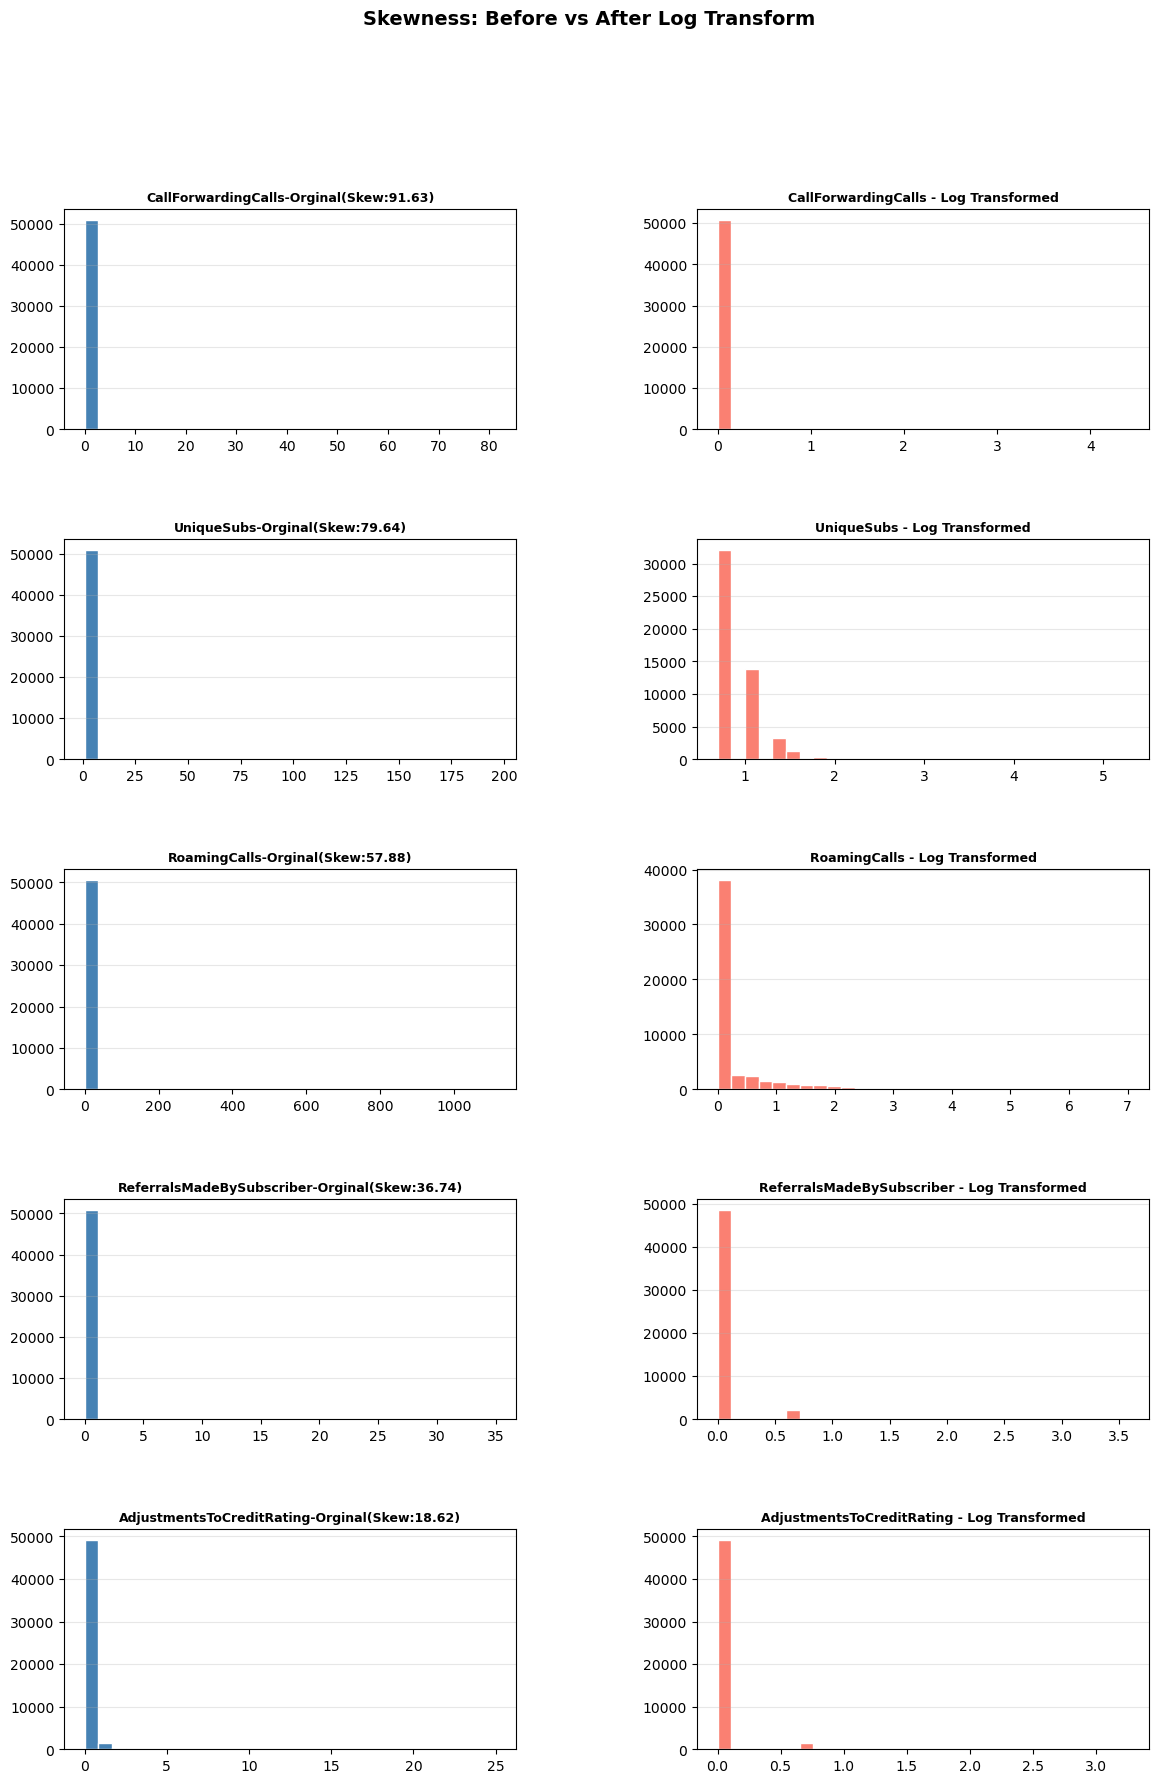

In [38]:
fig,axes=plt.subplots(5,2,figsize=(14,20))

most_skewed=skewness_df.head(5).index.tolist()

for i,col in enumerate(most_skewed):
    axes[i][0].hist(df[col].dropna(),bins=30,
                    color='steelblue',edgecolor='white')
    axes[i][0].set_title(f'{col}-Orginal(Skew:{skewness_df.loc[col,'Skewness']:.2f})',
                         fontsize=9,fontweight='bold')
    axes[i][0].grid(axis='y',alpha=0.3)


    axes[i][1].hist(np.log1p(df[col].dropna()),bins=30,
                    color='salmon',edgecolor='white')
    axes[i][1].set_title(f'{col} - Log Transformed', 
                         fontsize=9, fontweight='bold')
    axes[i][1].grid(axis='y', alpha=0.3)

plt.suptitle('Skewness: Before vs After Log Transform', 
             fontsize=14, fontweight='bold')
plt.subplots_adjust(hspace=0.5, wspace=0.4)

In [39]:
negative_cols = [col for col in df.select_dtypes(
    include=['int64','float64']).columns 
    if df[col].min() < 0]

print(negative_cols)

['MonthlyRevenue', 'TotalRecurringCharge', 'PercChangeMinutes', 'PercChangeRevenues', 'CurrentEquipmentDays']


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

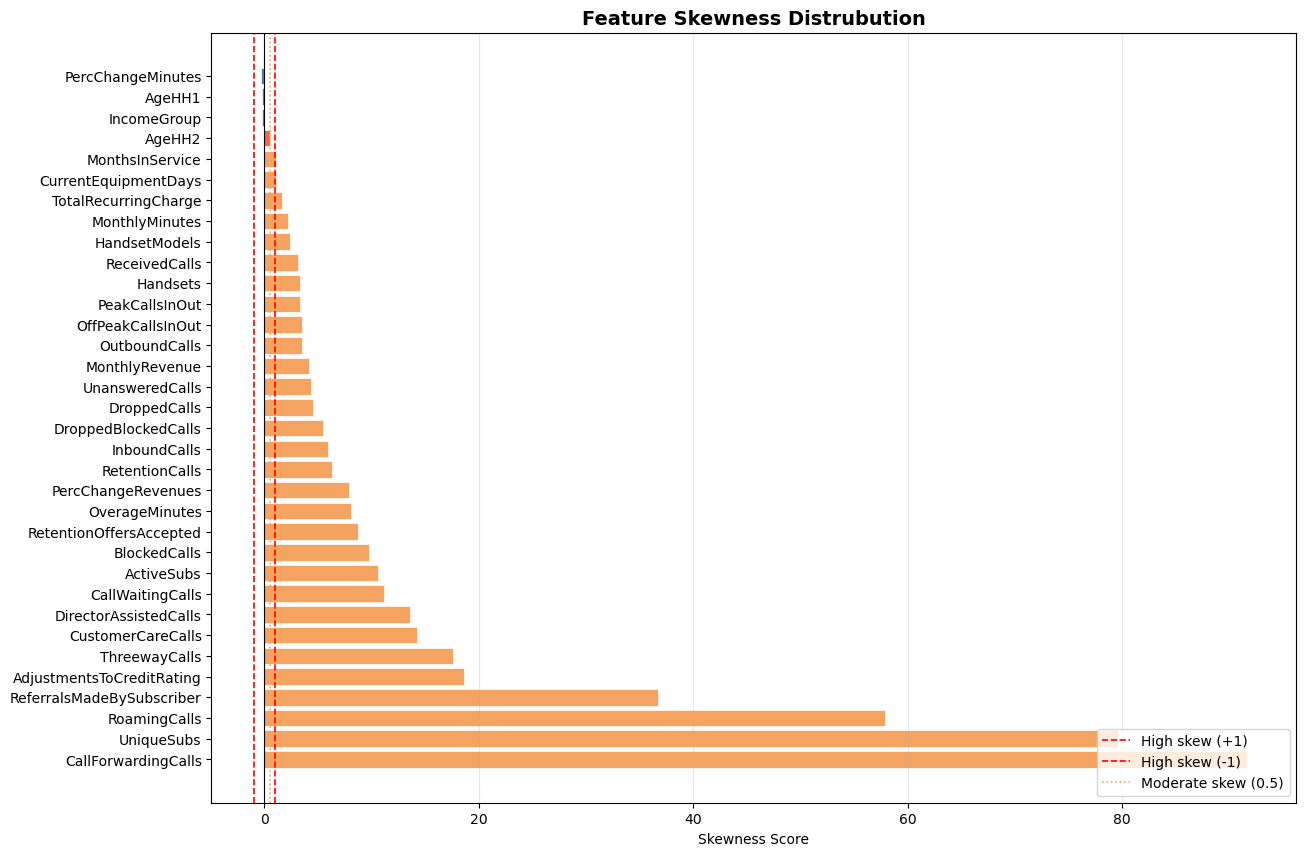

In [40]:
fig,ax=plt.subplots(figsize=(14,10))

colors_skew=['sandybrown' if abs(s)>=1 else 
             'tomato' if abs(s)>=0.5 else
             'steelblue' for s in skewness_df['Skewness']]

bars=ax.barh(skewness_df.index,skewness_df['Skewness'],
            color=colors_skew,edgecolor='white',linewidth=0.5)

ax.axvline(x=1,color='red',linestyle='--',linewidth=1.2,
           label='High skew (+1)')
ax.axvline(x=-1, color='red', linestyle='--', linewidth=1.2, 
           label='High skew (-1)')
ax.axvline(x=0.5, color='sandybrown', linestyle=':', linewidth=1.2, 
           label='Moderate skew (0.5)')
ax.axvline(x=0, color='black', linewidth=0.8)

ax.set_title('Feature Skewness Distrubution',fontsize=14,fontweight='bold')
ax.set_xlabel('Skewness Score')
ax.legend(loc='lower right')
ax.grid(axis='x',alpha=0.3)
plt.tight_layout

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

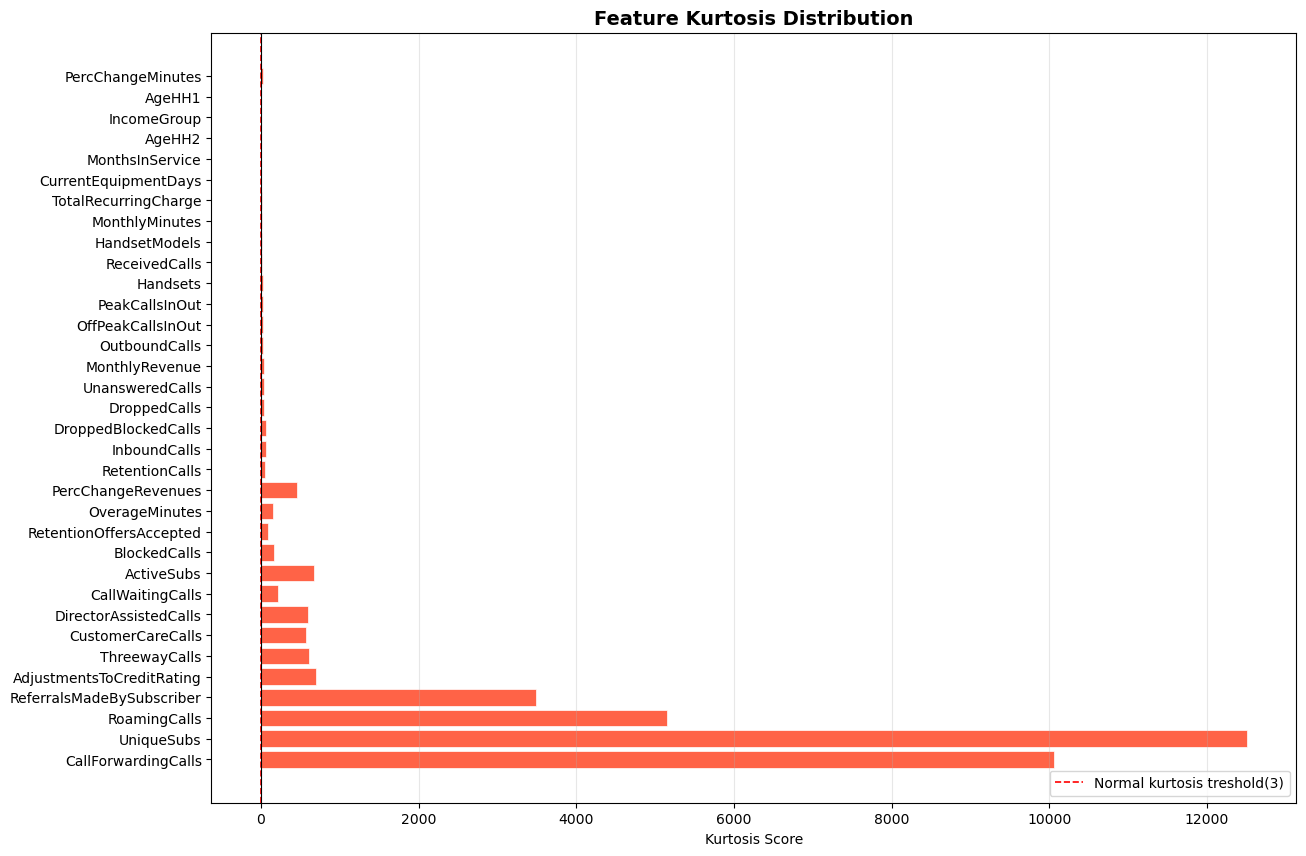

In [41]:
fig,ax=plt.subplots(figsize=(14,10))

colors_kurt=['tomato' if k>3 else 'steelblue'
             for k in skewness_df['Kurtosis']]

ax.barh(skewness_df.index,skewness_df['Kurtosis'],
        color=colors_kurt,edgecolor='white',linewidth=0.5)

ax.axvline(x=3,color='red',linestyle='--',linewidth=1.2,
           label='Normal kurtosis treshold(3)')

ax.axvline(x=0,color='black',linewidth=0.8)

ax.set_title('Feature Kurtosis Distribution',fontsize=14,fontweight='bold')
ax.set_xlabel('Kurtosis Score')
ax.legend(loc='lower right')
ax.grid(axis='x',alpha=0.3)
plt.tight_layout

### Zero inflated columns

In [42]:

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [col for col in num_cols if col != 'Churn']
zero_inflated = []

for col in num_cols:
    zero_pct = (df[col] == 0).sum() / len(df) * 100
    if zero_pct >= 70:
        zero_inflated.append((col, round(zero_pct, 2)))

zero_inflated_df = pd.DataFrame(zero_inflated, 
                                 columns=['Column', 'Zero %']).sort_values(
                                 'Zero %', ascending=False)
print(zero_inflated_df)

                      Column  Zero %
1        CallForwardingCalls   99.54
3    RetentionOffersAccepted   98.27
2             RetentionCalls   96.58
5  AdjustmentsToCreditRating   96.40
4  ReferralsMadeBySubscriber   95.33
0              ThreewayCalls   72.74


In [43]:
leakage_cols=['RetentionCalls',
'RetentionOffersAccepted',
'MadeCallToRetentionTeam']

In [ ]:
# Finding pair columns
binary_cols = [col for col in df.columns 
               if df[col].nunique() == 2 
               and df[col].dtype in ['int64', 'float64']]

inverse_pairs = []

for i, col1 in enumerate(binary_cols):
    for col2 in binary_cols[i+1:]:
        if df[col1].equals(1 - df[col2]):
            inverse_pairs.append((col1, col2))

print("Inverse pairs found:")
for pair in inverse_pairs:
    print(f"  {pair[0]}  <-->  {pair[1]}")

cols_to_drop = [pair[1] for pair in inverse_pairs]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"\nRemoved: {cols_to_drop}")
print(f"Remaining columns: {df.shape[1]}")

Inverse pairs found:

Removed: []
Remaining columns: 58


In [45]:
for col in df.columns:
    if df[col].dtype != 'object':
        bad_values = df[col].apply(lambda x: isinstance(x, str)).sum()
        if bad_values > 0:
            print(col, "contains string inside numeric column")

In [46]:
df.columns

Index(['CustomerID', 'Churn', 'MonthlyRevenue', 'MonthlyMinutes',
       'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes',
       'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues',
       'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls',
       'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls',
       'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls',
       'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService',
       'UniqueSubs', 'ActiveSubs', 'ServiceArea', 'Handsets', 'HandsetModels',
       'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'ChildrenInHH',
       'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner',
       'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers',
       'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard',
       'RetentionCalls', 'RetentionOffersAccepted', 'NewCellphoneUser',
       'NotNewCellphoneUser', 'ReferralsMadeBySubscriber', 'IncomeGro

In [47]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"{col} ({len(unique_vals)} unique): {unique_vals}")

ServiceArea (748 unique): ['SEAPOR503' 'PITHOM412' 'MILMIL414' 'OKCTUL918' 'OKCOKC405' 'SANMCA210'
 'SLCSLC801' 'LOULOU502' 'KCYKCK913' 'KCYNEW316' 'KCYKCM816' 'DENDEN303'
 'PHICTR610' 'OKCLRK501' 'OMADES515' 'SANAUS512' 'KCYWIC316' 'INDIND317'
 'SLCPRO801' 'OMALNC402' 'NSHNSH615' 'OMAOMA402' 'PHXTUC520' 'DALDAL214'
 'DALDTN940' 'DALFTW817' 'SANSAN210' 'NYCMAN917' 'NOLKEN504' 'MINMIN612'
 'NNYROC716' 'PHIARD610' 'NYCQUE917' 'DENBOU303' 'BOSBOS617' 'PHXPHX602'
 'NNYBUF716' 'DETTOL419' 'NNYSYR315' 'STLSTL314' 'PHIPHI215' 'SEABLV425'
 'MIAMIA305' 'PHICHC215' 'SEASEA206' 'BIRBIR205' 'MIADFD954' 'LOUNAL812'
 'MIADEL561' 'MIAFTL954' 'SEASPO509' 'SEATAC253' 'SFRSAC916' 'MIANDA305'
 'MINSTP612' 'MIAHWD954' 'NYCBRO917' 'PHIJEN215' 'OMACDR319' 'MIAWPB561'
 'SEAOLY360' 'PITBUT412' 'SEAEVE425' 'PHIMER609' 'SEACDA208' 'HARHAR860'
 'SFRSFR415' 'SFROAK510' 'SFRSCL408' 'NNYALB518' 'STLCOL618' 'NYCNEW201'
 'SFRPAL650' 'DETDET313' 'DETROS810' 'NYCNEW908' 'NYCNAS516' 'NSHCOL615'
 'PITGRE412' 'SEABEA503' 

## EDA Key Findings

### 1. Class Imbalance
- Despite the dataset being described as "balanced", actual distribution 
  revealed 71% non-churned vs 29% churned customers.
- SMOTE was applied during modeling to address this imbalance.

### 2. Missing Value Analysis
- All missing values were below 2% — dataset is relatively complete.
- Missing values in key features carried predictive signal:
  - Handsets, CurrentEquipmentDays, HandsetModels: churn rate = 0.000 
    for NaN rows — these are new customers.
  - PercChangeMinutes, PercChangeRevenues: churn rate = 0.567 for NaN 
    rows — high churn risk among customers with no previous month data.
  - AgeHH1, AgeHH2: difference of only 0.015 — random missing, 
    no predictive signal.

### 3. Feature Correlation with Churn
- No single feature showed strong linear correlation with churn (max: 0.10).
- This suggests churn is driven by complex interactions between multiple 
  features rather than any individual variable.
- Tree-based ensemble models (XGBoost, Random Forest) are more suitable 
  for this dataset.

### 4. Skewness Analysis
- Several features showed extreme right skewness (CallForwardingCalls: 91.6, 
  UniqueSubs: 79.6) due to zero-inflation.
- Zero-inflated features were binarized rather than log-transformed.
- Remaining skewed features were handled via log transformation in pipeline.

### 5. Zero-Inflated Features
- RetentionCalls (96.6%), AdjustmentsToCreditRating (96.4%), 
  ReferralsMadeBySubscriber (95.3%), ThreewayCalls (72.7%) — 
  binarized to capture whether event occurred rather than count.

### 6. Outliers
- Significant outliers detected in usage-related features.
- Handled via OutlierCapper (1%-99% percentile) in preprocessing pipeline.

### 7. Quasi-Constant Features
- 4 features exceeded 98% quasi-constant threshold and were removed 
  as they carry no discriminative information.

### 8. Multicollinearity
- No feature pairs exceeded 0.8 correlation threshold among numeric features.
- Missing flag columns showed perfect correlation (1.0) where identical 
  records were missing — redundant flags were removed.

## Feature Engineering

In [48]:
df.drop('CustomerID',axis=1,inplace=True)

In [ ]:
# 156 NaN columns
cols_156 = ['RoamingCalls', 'OverageMinutes', 'DirectorAssistedCalls', 
            'TotalRecurringCharge', 'MonthlyMinutes', 'MonthlyRevenue']

# Bu sütunların hamısında eyni anda NaN olan sətir sayı
same_rows = df[cols_156].isnull().all(axis=1).sum()
print(f"Hamısında eyni anda NaN olan sətir sayı: {same_rows}")

# Yoxlama — hər sütundakı NaN sətirləri eyni mi?
nan_indices = [set(df[df[col].isna()].index) for col in cols_156]
all_same = all(s == nan_indices[0] for s in nan_indices)
print(f"Hamısının NaN sətirləri eynidir: {all_same}")

Hamısında eyni anda NaN olan sətir sayı: 156
Hamısının NaN sətirləri eynidir: True


In [50]:
# RoamingCalls selected as representative for the missing flag
# because roaming activity is the most behaviorally distinctive feature
# among the 6 columns — customers without roaming calls are more likely
# to have limited usage profiles, which aligns with the missing pattern
df['Usage_missing'] = df['RoamingCalls'].isna().astype(int)


In [51]:
cols_367 = ['PercChangeMinutes', 'PercChangeRevenues']

same_rows_367 = df[cols_367].isnull().all(axis=1).sum()
nan_indices_367 = [set(df[df[col].isna()].index) for col in cols_367]
all_same_367 = all(s == nan_indices_367[0] for s in nan_indices_367)

print(f"NaN rows identical: {all_same_367}")
print(f"Total identical NaN rows: {same_rows_367}")

NaN rows identical: True
Total identical NaN rows: 367


In [52]:
df['PercChange_missing'] = df['PercChangeMinutes'].isna().astype(int)

In [53]:
# Only 1 NaN each — dropping these rows instead of creating flags
df.dropna(subset=['Handsets', 'CurrentEquipmentDays', 'HandsetModels'], inplace=True)

In [54]:
# --- Removing Quasi-Constant Features ---
# Identified during EDA — these features show near-zero variance
# and carry no predictive signal for churn
df.drop(columns=quasi_constant_cols, inplace=True)

print(f"Removed {len(quasi_constant_cols)} quasi-constant features")
print(f"Remaining columns: {df.shape[1]}")

Removed 4 quasi-constant features
Remaining columns: 55


In [55]:
# --- Removing Highly Correlated Features ---
# Features with correlation > 0.8 identified during EDA
# Removed to avoid multicollinearity
df.drop(columns=to_drop, inplace=True, errors='ignore')
print(f"Removed correlated features: {to_drop}")
print(f"Remaining columns: {df.shape[1]}")

Removed correlated features: ['ReceivedCalls', 'DroppedBlockedCalls', 'HandsetModels']
Remaining columns: 52


In [56]:
# ---New Feature Creation ---
# New features were engineered based on Cohen's d analysis and telecom domain knowledge
# Features with highest effect size were combined to capture complex churn patterns
# that individual features cannot express alone

df['CustomerValue'] = df['MonthsInService'] * df['MonthlyRevenue']

df['ProblemCallRate'] = (df['DroppedCalls'] + df['BlockedCalls']) / (df['MonthlyMinutes'] + 1)

df['TenureEquipmentRatio'] = df['MonthsInService'] / (df['CurrentEquipmentDays'].clip(lower=0) + 1)

In [57]:
df.columns

Index(['Churn', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge',
       'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls',
       'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls',
       'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls',
       'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut',
       'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs',
       'ServiceArea', 'Handsets', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2',
       'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner',
       'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers',
       'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'RetentionCalls',
       'NewCellphoneUser', 'NotNewCellphoneUser', 'ReferralsMadeBySubscriber',
       'IncomeGroup', 'AdjustmentsToCreditRating', 'HandsetPrice',
       'MadeCallToRetentionTeam', 'CreditRating', 'PrizmCode', 'Occupation',
       'MaritalStatus', 'U

In [58]:
# --- 3.3 Zero-Inflated Feature Binarization ---
# Features with 95%+ zero values were converted to binary (0/1)
# Rationale: when a feature is overwhelmingly zero, the meaningful signal
# is whether the event occurred at all, not how many times it occurred
# Count-based representation adds noise without predictive value

df['CreditRatingAdjusted'] = (df['AdjustmentsToCreditRating'] > 0).astype(int)
df.drop(columns=['AdjustmentsToCreditRating'], inplace=True)

# Customer made referrals — loyalty indicator
df['MadeReferral'] = (df['ReferralsMadeBySubscriber'] > 0).astype(int)
df.drop(columns=['ReferralsMadeBySubscriber'], inplace=True)

# Three-way call usage — active service engagement
df['ThreewayCalls_used'] = (df['ThreewayCalls'] > 0).astype(int)
df.drop(columns=['ThreewayCalls'], inplace=True)

print(f"Remaining columns: {df.shape[1]}")

Remaining columns: 55


In [59]:
df.drop(columns=leakage_cols, inplace=True, errors='ignore')

In [60]:
df['HandsetPrice'] = df['HandsetPrice'].replace('Unknown', np.nan)
df['HandsetPrice'] = pd.to_numeric(df['HandsetPrice'], errors='coerce')

print(f"NaN count: {df['HandsetPrice'].isna().sum()}")
print(f"Dtype: {df['HandsetPrice'].dtype}")
print(df['HandsetPrice'].describe())

NaN count: 28981
Dtype: float64
count    22065.000000
mean        82.237933
std         60.401984
min         10.000000
25%         30.000000
50%         60.000000
75%        130.000000
max        500.000000
Name: HandsetPrice, dtype: float64


In [61]:
df['HandsetPrice'].isna().sum()

np.int64(28981)

In [62]:
df = df.drop('HandsetPrice', axis=1)

In [63]:
feature_diff = {}
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols = [col for col in num_cols if col != 'Churn']

for col in num_cols:
    mean_0 = df[df['Churn'] == 0][col].mean()
    mean_1 = df[df['Churn'] == 1][col].mean()
    std = df[col].std()
    feature_diff[col] = abs(mean_1 - mean_0) / std if std > 0 else 0

feature_diff_df = pd.Series(feature_diff).sort_values(ascending=False)
print(feature_diff_df.head(15))

CurrentEquipmentDays    0.228929
TotalRecurringCharge    0.135361
PercChange_missing      0.115558
MonthlyMinutes          0.110846
OffPeakCallsInOut       0.090066
PeakCallsInOut          0.088403
CustomerCareCalls       0.078412
UniqueSubs              0.076209
PercChangeMinutes       0.075672
InboundCalls            0.075595
Handsets                0.072519
OutboundCalls           0.071282
AgeHH1                  0.065689
UnansweredCalls         0.064822
ThreewayCalls_used      0.064530
dtype: float64


In [64]:
print(f"Final shape: {df.shape}")
print(f"\nRemaining object columns:")
print(df.select_dtypes(include='object').columns.tolist())
print(f"\nTotal NaN remaining:")
print(df.isna().sum().sum())

Final shape: (51046, 52)

Remaining object columns:
['ServiceArea', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus']

Total NaN remaining:
3824


In [65]:
corr_matrix = df[num_cols].corr().abs()
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i,j] > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i,j], 3)
            ))

for pair in high_corr_pairs:
    print(f"{pair[0]}  <-->  {pair[1]}  :  {pair[2]}")

In [66]:
# Top 10 most frequent ServiceArea values
top10_areas = df['ServiceArea'].value_counts().head(10).index

df['ServiceArea'] = df['ServiceArea'].apply(
    lambda x: x if x in top10_areas else 'Others')

print(f"Unique values: {df['ServiceArea'].nunique()}")
print(df['ServiceArea'].value_counts())

Unique values: 11
ServiceArea
Others       40996
NYCBRO917     1684
HOUHOU281     1510
DALDAL214     1498
NYCMAN917     1182
APCFCH703      783
DALFTW817      782
SANSAN210      724
APCSIL301      670
SANAUS512      612
SFROAK510      605
Name: count, dtype: int64


## Preprocessing

In [68]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\ny_train distribution:")
print(y_train.value_counts(normalize=True) * 100)
print(f"\ny_test distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (40836, 51)
X_test shape:  (10210, 51)

y_train distribution:
Churn
0    71.179841
1    28.820159
Name: proportion, dtype: float64

y_test distribution:
Churn
0    71.185113
1    28.814887
Name: proportion, dtype: float64


In [69]:
# Yes/No
yes_no_cols = ['ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable',
               'TruckOwner', 'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers',
               'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser',
               'NotNewCellphoneUser']

# Known/Unknown
#homeownership_col = ['Homeownership']

# Ordinal
ordinal_cols = ['CreditRating']

# One-hot
onehot_cols = ['PrizmCode', 'Occupation', 'MaritalStatus','Homeownership','ServiceArea']



In [74]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_pct=0.01, upper_pct=0.99):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.lower_bounds_ = X.quantile(self.lower_pct)
        self.upper_bounds_ = X.quantile(self.upper_pct)
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].clip(
                lower=self.lower_bounds_[col],
                upper=self.upper_bounds_[col]
            )
        return X.values

In [76]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01):
        self.threshold = threshold

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.rare_maps_ = {}
        for col in X.select_dtypes(include='object').columns:
            freq = X[col].value_counts(normalize=True)
            self.rare_maps_[col] = freq[freq < self.threshold].index
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col, rares in self.rare_maps_.items():
            X[col] = X[col].replace(rares, 'Rare')
        return X

In [77]:
class YeoJohnsonTransformer(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        
        # yalnız numeric sütunlar
        numeric_cols = X.select_dtypes(include=np.number).columns
        
        # binary sütunları çıxar (0/1 və ya 2 unique)
        self.cols_ = [
            col for col in numeric_cols
            if X[col].nunique() > 2
        ]
        
        # yalnız seçilmiş sütunlara fit
        self.pt_ = PowerTransformer(method='yeo-johnson')
        
        if len(self.cols_) > 0:
            self.pt_.fit(X[self.cols_])
        
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        
        if len(self.cols_) > 0:
            X[self.cols_] = self.pt_.transform(X[self.cols_])
        
        return X

In [ ]:
# 1. num_cols 
num_cols = [col for col in X_train.select_dtypes(
    include=['int64', 'float64']).columns.tolist()
    if col != 'Churn' 
    and col not in yes_no_cols 
    and col not in ordinal_cols]

# 2. Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['No', 'Yes']] * len(yes_no_cols)))
])

onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

# 3. preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('bin', binary_transformer, yes_no_cols),
        ('ord', ordinal_transformer, ordinal_cols),
        ('oh',  onehot_transformer, onehot_cols)
    ]
)

print(f"num_cols: {len(num_cols)}")
print(f"preprocessor num: {len(preprocessor.transformers[0][2])}")

num_cols: 33
preprocessor num: 33


In [ ]:
# Pipeline
def build_pipeline(model):
    return ImbPipeline([
        ('rare_category', RareCategoryGrouper()),  
        ('preprocessor', preprocessor),             
        ('cap_outliers', OutlierCapper()),
        ('fix_skewness', YeoJohnsonTransformer()),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

models = {
    "Logistic Regression": LogisticRegression(
        C=0.1,
        penalty="l2",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        scale_pos_weight=2.47,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
}

In [91]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'Training: {name} ...')
    pipe = build_pipeline(model)

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_pr_auc=cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=-1)
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        'pipeline' : pipe,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'cv_auc'   : cv_auc,
        'cv_pr_auc':cv_pr_auc,
        'test_auc' : roc_auc_score(y_test, y_prob),
        'test_pr_auc' : average_precision_score(y_test, y_prob),
        'f1'       : f1_score(y_test, y_pred, pos_label=1),
        'precision': precision_score(y_test, y_pred, pos_label=1),
        'recall'   : recall_score(y_test, y_pred, pos_label=1)

    }

    print(f'  CV AUC  : {cv_auc.mean():.4f} (+/- {cv_auc.std():.4f})')
    print(f'  CV PR AUC  : {cv_pr_auc.mean():.4f} (+/- {cv_pr_auc.std():.4f})')
    print(f'  Test AUC: {results[name]["test_auc"]:.4f}')
    print(f'  Test PR AUC: {results[name]["test_pr_auc"]:.4f}')
    print(f'  F1      : {results[name]["f1"]:.4f}')
    print(f'  Precision: {results[name]["precision"]:.4f}')
    print(f'  Recall  : {results[name]["recall"]:.4f}')
    print()

Training: Logistic Regression ...
  CV AUC  : 0.6138 (+/- 0.0076)
  CV PR AUC  : 0.3751 (+/- 0.0061)
  Test AUC: 0.6138
  Test PR AUC: 0.3708
  F1      : 0.4511
  Precision: 0.3625
  Recall  : 0.5969

Training: XGBoost ...
  CV AUC  : 0.6732 (+/- 0.0072)
  CV PR AUC  : 0.4470 (+/- 0.0068)
  Test AUC: 0.6726
  Test PR AUC: 0.4523
  F1      : 0.4953
  Precision: 0.3853
  Recall  : 0.6934

Training: Random Forest ...
  CV AUC  : 0.6390 (+/- 0.0058)
  CV PR AUC  : 0.3876 (+/- 0.0072)
  Test AUC: 0.6360
  Test PR AUC: 0.3874
  F1      : 0.3514
  Precision: 0.4219
  Recall  : 0.3012



In [ ]:
#Table of results
results_df = pd.DataFrame({
    name: {
        'CV AUC': results[name]['cv_auc'].mean(),
        'CV PR AUC': results[name]['cv_pr_auc'].mean(),
        'Test AUC': results[name]['test_auc'],
        'Test PR AUC': results[name]['test_pr_auc'],
        'F1': results[name]['f1'],
        'Precision': results[name]['precision'],
        'Recall': results[name]['recall']
    }
    for name in results
}).T.round(4)

print(results_df)

                     CV AUC  CV PR AUC  Test AUC  Test PR AUC      F1  \
Logistic Regression  0.6138     0.3751    0.6138       0.3708  0.4511   
XGBoost              0.6732     0.4470    0.6726       0.4523  0.4953   
Random Forest        0.6390     0.3876    0.6360       0.3874  0.3514   

                     Precision  Recall  
Logistic Regression     0.3625  0.5969  
XGBoost                 0.3853  0.6934  
Random Forest           0.4219  0.3012  


C:\Users\HP\AppData\Local\Temp\ipykernel_14344\1318480660.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
C:\Users\HP\AppData\Local\Temp\ipykernel_14344\1318480660.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
C:\Users\HP\AppData\Local\Temp\ipykernel_14344\1318480660.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
C:\Users\HP\AppData\Local\Temp\ipykernel_14344\1318480660.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xtickl

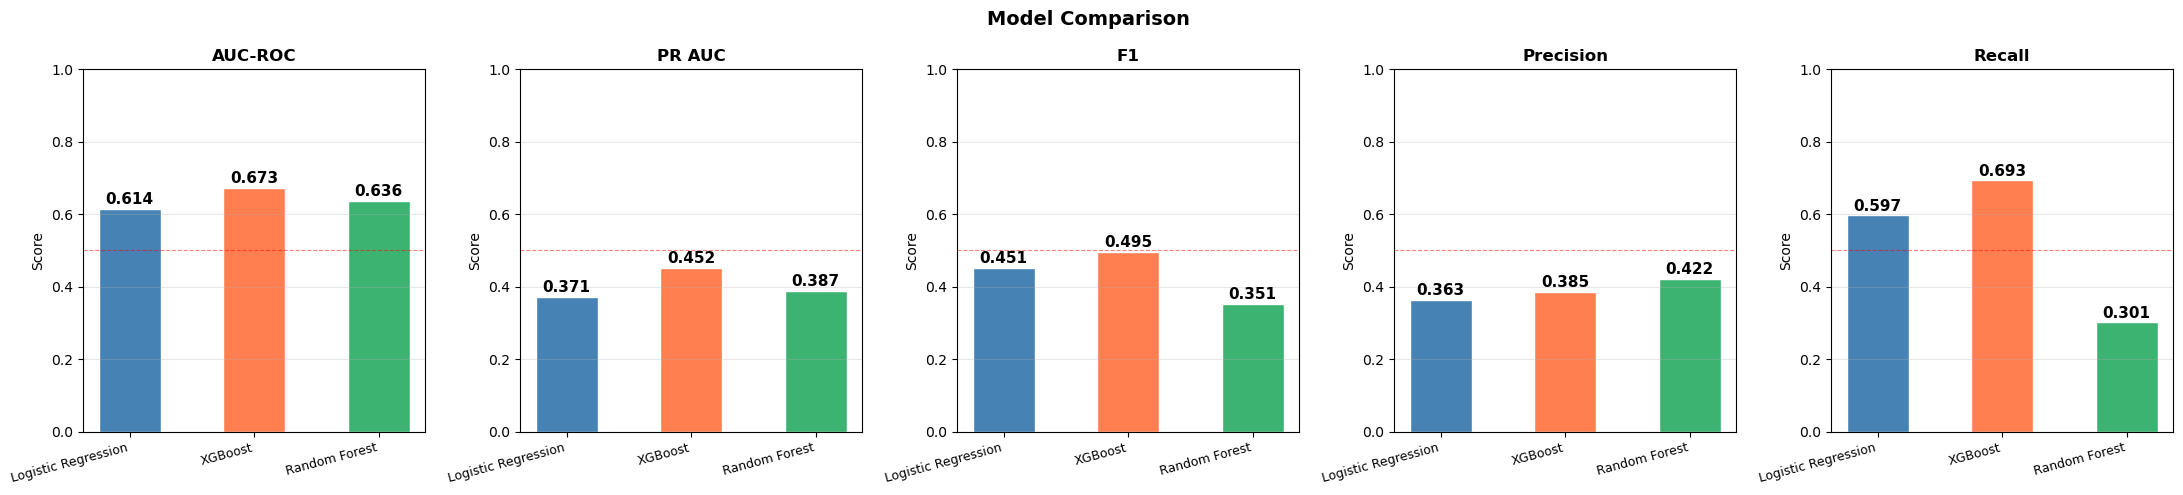

In [127]:
metric_names = ['AUC-ROC', 'PR AUC', 'F1', 'Precision', 'Recall']
metric_keys  = ['test_auc', 'test_pr_auc', 'f1', 'precision', 'recall']
model_names  = list(results.keys())
colors       = ['steelblue', 'coral', 'mediumseagreen']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

for ax, metric_name, metric_key in zip(axes, metric_names, metric_keys):
    values = [results[m][metric_key] for m in model_names]
    bars = ax.bar(model_names, values, color=colors, 
                  edgecolor='white', width=0.5)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', 
            fontsize=11, fontweight='bold'
        )

    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0.5, color='red', linestyle='--', 
               linewidth=0.8, alpha=0.5, label='Baseline')

plt.tight_layout()
plt.show()

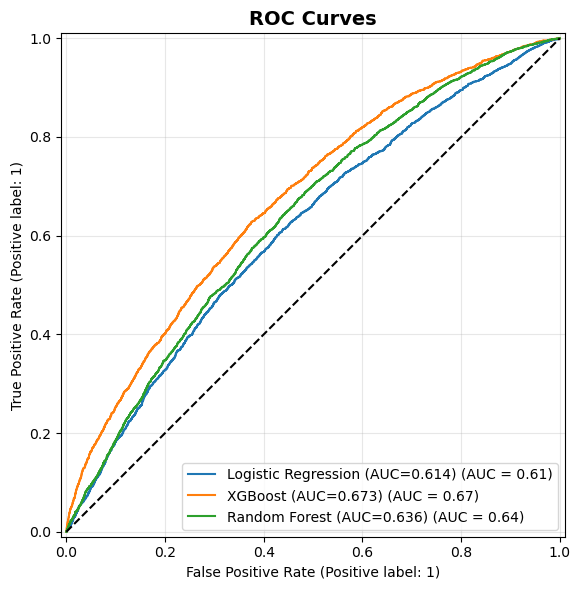

In [ ]:
# ROC curve
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name in results:
    RocCurveDisplay.from_predictions(
        y_test,
        results[name]['y_prob'],
        ax=ax,
        name=f"{name} (AUC={results[name]['test_auc']:.3f})"
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

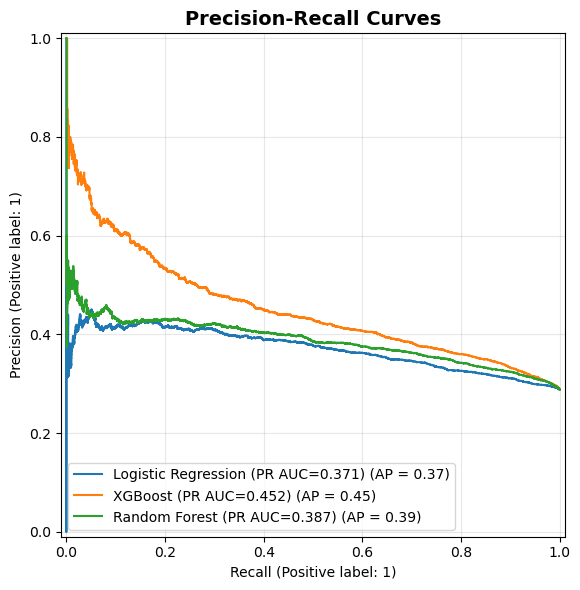

In [ ]:
# PR curve
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name in results:
    PrecisionRecallDisplay.from_predictions(
        y_test,
        results[name]['y_prob'],
        ax=ax,
        name=f"{name} (PR AUC={results[name]['test_pr_auc']:.3f})"
    )

ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

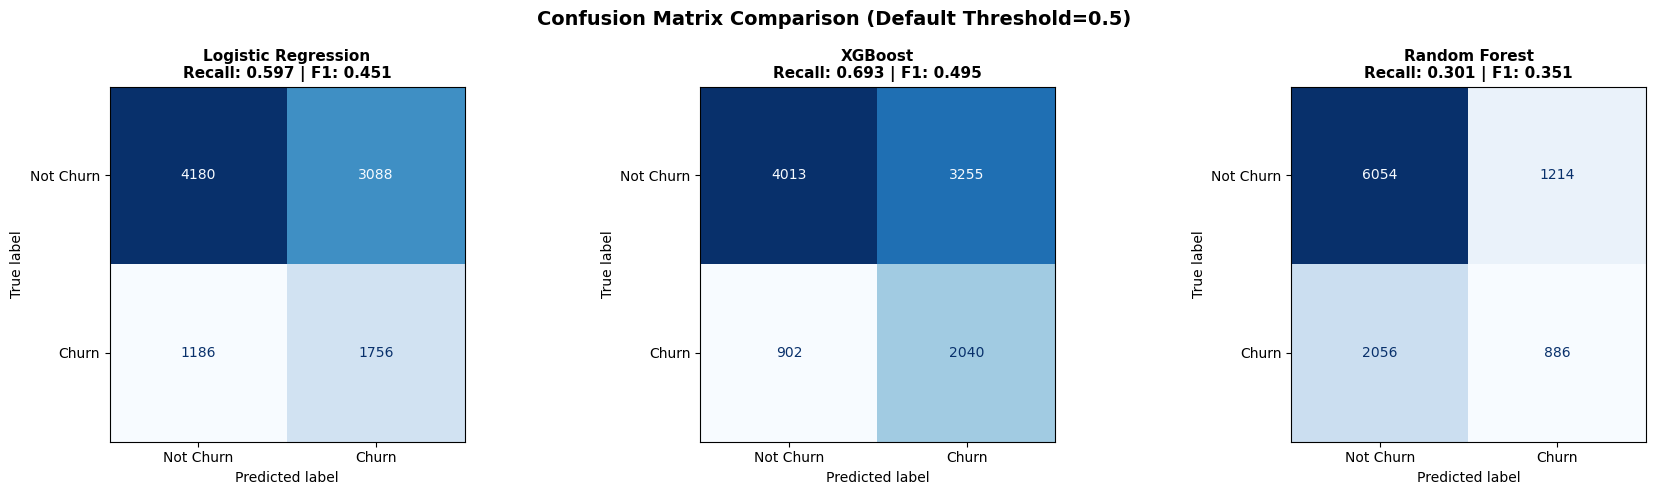

In [128]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, results.keys()):
    # Default threshold ilə
    y_pred_model = results[name]['y_pred']
    
    cm = confusion_matrix(y_test, y_pred_model)
    
    ConfusionMatrixDisplay(cm, display_labels=['Not Churn', 'Churn']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    
    recall = results[name]['recall']
    f1 = results[name]['f1']
    
    ax.set_title(f'{name}\nRecall: {recall:.3f} | F1: {f1:.3f}', 
                 fontsize=11, fontweight='bold')

fig.suptitle('Confusion Matrix Comparison (Default Threshold=0.5)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Importance

In [ ]:
# XGBoost pipeline-dan feature importance çıxart
xgb_pipe = results['XGBoost']['pipeline']

# Find fearure names after preprocessing
onehot_feature_names = list(
    xgb_pipe.named_steps['preprocessor']
    .named_transformers_['oh']
    .get_feature_names_out(onehot_cols)
)

ordinal_feature_names = ordinal_cols

all_feature_names = num_cols + yes_no_cols + ordinal_feature_names + onehot_feature_names

# Feature importance
importances = xgb_pipe.named_steps['model'].feature_importances_

importance_df = pd.Series(importances, 
                          index=all_feature_names).sort_values(ascending=False)

print(importance_df)

PrizmCode_Suburban         0.078224
ServiceArea_Others         0.071431
NewCellphoneUser           0.055437
PrizmCode_Other            0.051044
MaritalStatus_No           0.044289
HandsetRefurbished         0.042953
RespondsToMailOffers       0.039246
ChildrenInHH               0.035795
NotNewCellphoneUser        0.035343
TruckOwner                 0.034037
Occupation_Other           0.033092
CreditRating               0.030866
OwnsComputer               0.030021
MaritalStatus_Unknown      0.029967
HandsetWebCapable          0.027050
PrizmCode_Town             0.026527
MonthsInService            0.023922
HasCreditCard              0.016403
Handsets                   0.014904
DirectorAssistedCalls      0.012807
UniqueSubs                 0.012114
Occupation_Professional    0.011375
BuysViaMailOrder           0.011056
CurrentEquipmentDays       0.009392
ThreewayCalls_used         0.009352
ActiveSubs                 0.009239
OverageMinutes             0.008741
TenureEquipmentRatio       0

In [153]:
for threshold in [0.80, 0.85, 0.90, 0.95]:
    cumulative = importance_df.cumsum()
    selected = importance_df[cumulative <= threshold].index.tolist()
    dropped = importance_df[cumulative > threshold].index.tolist()
    print(f"Threshold {threshold*100:.0f}%: {len(selected)} keep, {len(dropped)} drop")

Threshold 80%: 26 keep, 47 drop
Threshold 85%: 32 keep, 41 drop
Threshold 90%: 41 keep, 32 drop
Threshold 95%: 53 keep, 20 drop


In [ ]:
# Finding old feature names from preprocessing
all_feature_names = (num_cols + yes_no_cols + 
                     ordinal_cols +
                     list(results['XGBoost']['pipeline']
                          .named_steps['preprocessor']
                          .named_transformers_['oh']
                          .get_feature_names_out(onehot_cols)))

# 
X_train_processed = results['XGBoost']['pipeline'].named_steps['preprocessor'].transform(X_train)
X_train_processed = pd.DataFrame(X_train_processed, columns=all_feature_names)

X_test_processed = results['XGBoost']['pipeline'].named_steps['preprocessor'].transform(X_test)
X_test_processed = pd.DataFrame(X_test_processed, columns=all_feature_names)

for threshold in [0.85, 0.90]:
    cumulative = importance_df.cumsum()
    selected = importance_df[cumulative <= threshold].index.tolist()
    
    X_train_sel = X_train_processed[selected]
    X_test_sel = X_test_processed[selected]
    
    xgb_model = XGBClassifier(
        scale_pos_weight=2.47,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train_sel, y_train)
    
    xgb_model.fit(X_res, y_res)
    y_prob = xgb_model.predict_proba(X_test_sel)[:, 1]
    y_pred = xgb_model.predict(X_test_sel)
    
    print(f"\nThreshold {threshold*100:.0f}%: {len(selected)} features")
    print(f"Test AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print(f"F1:       {f1_score(y_test, y_pred):.4f}")
    print(f"Recall:   {recall_score(y_test, y_pred):.4f}")


Threshold 85%: 32 features
Test AUC: 0.6454
F1:       0.4857
Recall:   0.7267

Threshold 90%: 41 features
Test AUC: 0.6647
F1:       0.4923
Recall:   0.7077


In [141]:
selected_features = importance_df[cumulative <= 0.85].index.tolist()
dropped_features = importance_df[cumulative > 0.85].index.tolist()

print(f"Selected: {len(selected_features)}")
print(f"Dropped: {len(dropped_features)}")
print(f"\nDropped features:\n{dropped_features}")

Selected: 32
Dropped: 41

Dropped features:
['NonUSTravel', 'IncomeGroup', 'PrizmCode_Rural', 'AgeHH1', 'RoamingCalls', 'MonthlyMinutes', 'ServiceArea_APCSIL301', 'PercChangeMinutes', 'ServiceArea_HOUHOU281', 'CustomerCareCalls', 'Homeownership_Known', 'DroppedCalls', 'Occupation_Crafts', 'PeakCallsInOut', 'ProblemCallRate', 'InboundCalls', 'OffPeakCallsInOut', 'PercChangeRevenues', 'ServiceArea_DALDAL214', 'MonthlyRevenue', 'CustomerValue', 'ServiceArea_SFROAK510', 'ServiceArea_SANSAN210', 'OutboundCalls', 'AgeHH2', 'Occupation_Self', 'ServiceArea_NYCBRO917', 'RVOwner', 'MadeReferral', 'CreditRatingAdjusted', 'UnansweredCalls', 'ServiceArea_NYCMAN917', 'ServiceArea_SANAUS512', 'Occupation_Clerical', 'Occupation_Retired', 'ServiceArea_DALFTW817', 'Occupation_Rare', 'ServiceArea_APCFCH703', 'Homeownership_Unknown', 'Usage_missing', 'PercChange_missing']


In [142]:
# Drop low importance features from X_train and X_test
original_to_drop = [col for col in dropped_features 
                    if col in X_train.columns]

X_train_selected = X_train.drop(columns=original_to_drop)
X_test_selected = X_test.drop(columns=original_to_drop)

print(f"Dropped: {original_to_drop}")
print(f"X_train shape: {X_train_selected.shape}")

Dropped: ['NonUSTravel', 'IncomeGroup', 'AgeHH1', 'RoamingCalls', 'MonthlyMinutes', 'PercChangeMinutes', 'CustomerCareCalls', 'DroppedCalls', 'PeakCallsInOut', 'ProblemCallRate', 'InboundCalls', 'OffPeakCallsInOut', 'PercChangeRevenues', 'MonthlyRevenue', 'CustomerValue', 'OutboundCalls', 'AgeHH2', 'RVOwner', 'MadeReferral', 'CreditRatingAdjusted', 'UnansweredCalls', 'Usage_missing', 'PercChange_missing']
X_train shape: (40836, 28)


In [ ]:
# Update num_cols 
num_cols = [col for col in X_train_selected.select_dtypes(
    include=['int64', 'float64']).columns.tolist()
    if col not in yes_no_cols
    and col not in ordinal_cols]

# Update yes_no_cols
yes_no_cols = [col for col in yes_no_cols 
               if col in X_train_selected.columns]


# Update onehot_cols 
onehot_cols = [col for col in onehot_cols 
               if col in X_train_selected.columns]

# Update preprocessor 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('bin', binary_transformer, yes_no_cols),
        ('ord', ordinal_transformer, ordinal_cols),
        ('oh',  onehot_transformer, onehot_cols)
    ]
)

print(f"num_cols: {len(num_cols)}")
print(f"yes_no_cols: {len(yes_no_cols)}")
print(f"onehot_cols: {len(onehot_cols)}")

num_cols: 12
yes_no_cols: 10
onehot_cols: 5


In [132]:
X_train_selected.shape

(40836, 34)

In [ ]:
# Update Pipeline

num_cols = [col for col in X_train_selected.select_dtypes(
    include=['int64', 'float64']).columns.tolist()
    if col != 'Churn' 
    and col not in yes_no_cols 
    and col not in ordinal_cols]

yes_no_cols = [col for col in yes_no_cols 
               if col in X_train_selected.columns]

onehot_cols = [col for col in onehot_cols 
               if col in X_train_selected.columns]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['No', 'Yes']] * len(yes_no_cols)))
])

onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('bin', binary_transformer, yes_no_cols),
        ('ord', ordinal_transformer, ordinal_cols),
        ('oh',  onehot_transformer, onehot_cols)
    ]
)

print(f"num_cols: {len(num_cols)}")
print(f"yes_no_cols: {len(yes_no_cols)}")
print(f"onehot_cols: {len(onehot_cols)}")
print(f"preprocessor num: {len(preprocessor.transformers[0][2])}")

num_cols: 12
yes_no_cols: 10
onehot_cols: 5
preprocessor num: 12


## Modeling

In [ ]:
# Building model
results_selected = {}

for name, model in models.items():
    print(f'Training: {name} ...')
    pipe = build_pipeline(model)

    cv_auc = cross_val_score(pipe, X_train_selected, y_train, 
                              cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_pr_auc = cross_val_score(pipe, X_train_selected, y_train, 
                                 cv=cv, scoring='average_precision', n_jobs=-1)
    
    pipe.fit(X_train_selected, y_train)

    y_pred = pipe.predict(X_test_selected)
    y_prob = pipe.predict_proba(X_test_selected)[:, 1]

    results_selected[name] = {
        'pipeline'   : pipe,
        'y_pred'     : y_pred,
        'y_prob'     : y_prob,
        'cv_auc'     : cv_auc,
        'cv_pr_auc'  : cv_pr_auc,
        'test_auc'   : roc_auc_score(y_test, y_prob),
        'test_pr_auc': average_precision_score(y_test, y_prob),
        'f1'         : f1_score(y_test, y_pred, pos_label=1),
        'precision'  : precision_score(y_test, y_pred, pos_label=1),
        'recall'     : recall_score(y_test, y_pred, pos_label=1)
    }

    print(f'  CV AUC    : {cv_auc.mean():.4f} (+/- {cv_auc.std():.4f})')
    print(f'  CV PR AUC : {cv_pr_auc.mean():.4f} (+/- {cv_pr_auc.std():.4f})')
    print(f'  Test AUC  : {results_selected[name]["test_auc"]:.4f}')
    print(f'  Test PR AUC: {results_selected[name]["test_pr_auc"]:.4f}')
    print(f'  F1        : {results_selected[name]["f1"]:.4f}')
    print(f'  Precision : {results_selected[name]["precision"]:.4f}')
    print(f'  Recall    : {results_selected[name]["recall"]:.4f}')
    print()

Training: Logistic Regression ...
  CV AUC    : 0.5948 (+/- 0.0070)
  CV PR AUC : 0.3579 (+/- 0.0069)
  Test AUC  : 0.5985
  Test PR AUC: 0.3556
  F1        : 0.4346
  Precision : 0.3506
  Recall    : 0.5714

Training: XGBoost ...
  CV AUC    : 0.6477 (+/- 0.0066)
  CV PR AUC : 0.4052 (+/- 0.0030)
  Test AUC  : 0.6427
  Test PR AUC: 0.3978
  F1        : 0.4822
  Precision : 0.3639
  Recall    : 0.7145

Training: Random Forest ...
  CV AUC    : 0.6296 (+/- 0.0052)
  CV PR AUC : 0.3789 (+/- 0.0034)
  Test AUC  : 0.6279
  Test PR AUC: 0.3835
  F1        : 0.3950
  Precision : 0.3954
  Recall    : 0.3946



In [113]:
!pip install optuna
import optuna
from optuna.samplers import TPESampler



   ---------------------------------------- 0/4 [Mako]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ---------------------------------------- 4/4 [optuna]



In [ ]:
#Hyperparametr tuning(opyuna)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.5, 4.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 3),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
    }
    
    model = XGBClassifier(
        **params,
        eval_metric='logloss',
        random_state=42
    )
    
    pipe = build_pipeline(model)
    
    scores = cross_val_score(pipe, X_train_selected, y_train,
                              cv=cv, scoring='average_precision', n_jobs=-1)
    
    return scores.mean()

sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50,timeout=900, show_progress_bar=True)

print(f"\nBest PR AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-05-09 20:48:58,846] A new study created in memory with name: no-name-988f62da-bbc7-484e-9e5e-d91cf72303f2


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-09 20:49:07,430] Trial 0 finished with value: 0.4003197251928137 and parameters: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'scale_pos_weight': 1.6452090304204987, 'gamma': 4.330880728874676, 'reg_alpha': 1.2022300234864176, 'reg_lambda': 2.2701814444901136, 'max_delta_step': 0, 'colsample_bylevel': 0.9879639408647978}. Best is trial 0 with value: 0.4003197251928137.
[I 2026-05-09 20:49:17,767] Trial 1 finished with value: 0.3924875662178705 and parameters: {'n_estimators': 433, 'max_depth': 4, 'learning_rate': 0.01855998084649059, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.7216968971838151, 'min_child_weight': 6, 'scale_pos_weight': 2.5798625466052894, 'gamma': 1.4561457009902097, 'reg_alpha': 1.223705789444759, 'reg_lambda': 0.8487346516301046, 'max_delta_step': 3, 'colsample_bylevel': 0.7465447373174767}. Best is trial 0 with value: 0

In [147]:
best_params = study.best_params

best_xgb = XGBClassifier(
    **best_params,
    eval_metric='logloss',
    random_state=42
)

best_pipe = build_pipeline(best_xgb)
best_pipe.fit(X_train_selected, y_train)

y_pred_best = best_pipe.predict(X_test_selected)
y_prob_best = best_pipe.predict_proba(X_test_selected)[:, 1]

print(f"Test AUC:    {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"PR AUC:      {average_precision_score(y_test, y_prob_best):.4f}")
print(f"F1:          {f1_score(y_test, y_pred_best):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_best):.4f}")

Test AUC:    0.6455
PR AUC:      0.3986
F1:          0.4901
Precision:   0.3544
Recall:      0.7944


In [149]:
# Find optimal threshold using cross-validated predictions on training data
from sklearn.model_selection import cross_val_predict

y_prob_train = cross_val_predict(best_pipe, X_train_selected, y_train, 
                                  cv=cv, method='predict_proba')[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_prob_train)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
optimal_threshold = thresholds[f1_scores.argmax()]

print(f"Optimal threshold: {optimal_threshold:.3f}")

Optimal threshold: 0.485


In [ ]:
# Final evaluation — Feature Selection (85%) + Hyperparameter Tuning + Optimal Threshold
y_prob_selected = best_pipe.predict_proba(X_test_selected)[:, 1]
y_pred_final = (y_prob_selected >= optimal_threshold).astype(int)

print("="*50)
print("FINAL MODEL EVALUATION")
print("Feature Selection: 85% | Tuning: Optuna | Threshold:{optimal_threshold:.3f}")
print("="*50)
print(f"Test AUC:  {roc_auc_score(y_test, y_prob_selected):.4f}")
print(f"PR AUC:    {average_precision_score(y_test, y_prob_selected):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")

FINAL MODEL EVALUATION
Feature Selection: 85% | Tuning: Optuna | Threshold: 0.485
Test AUC:  0.6455
PR AUC:    0.3986
F1:        0.4884
Precision: 0.3483
Recall:    0.8171


In [154]:
# Final model — Feature Selection (85%) + Optuna Tuning + Threshold (0.485)
final_model = best_pipe
final_threshold = optimal_threshold
final_y_prob = y_prob_selected
final_y_pred = (final_y_prob >= final_threshold).astype(int)


In [156]:
final_model

Pipeline(steps=[('rare_category', RareCategoryGrouper()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['TotalRecurringCharge',
                                                   'DirectorAssistedCalls',
                                                   'OverageMinutes',
                                                   'BlockedCalls',
                                                   'CallWaitingCalls',
                                                   'MonthsInService',
                                                   'UniqueSubs', 'ActiveSubs',
                                                   'Hand...
                               gamma=1.68598186576173, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.06448742975759464, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=5, max_depth=4, max_leaves=None,
                               min_child_weight=3, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=427, n_jobs=None,
                               num_parallel_tree=None, ...))])

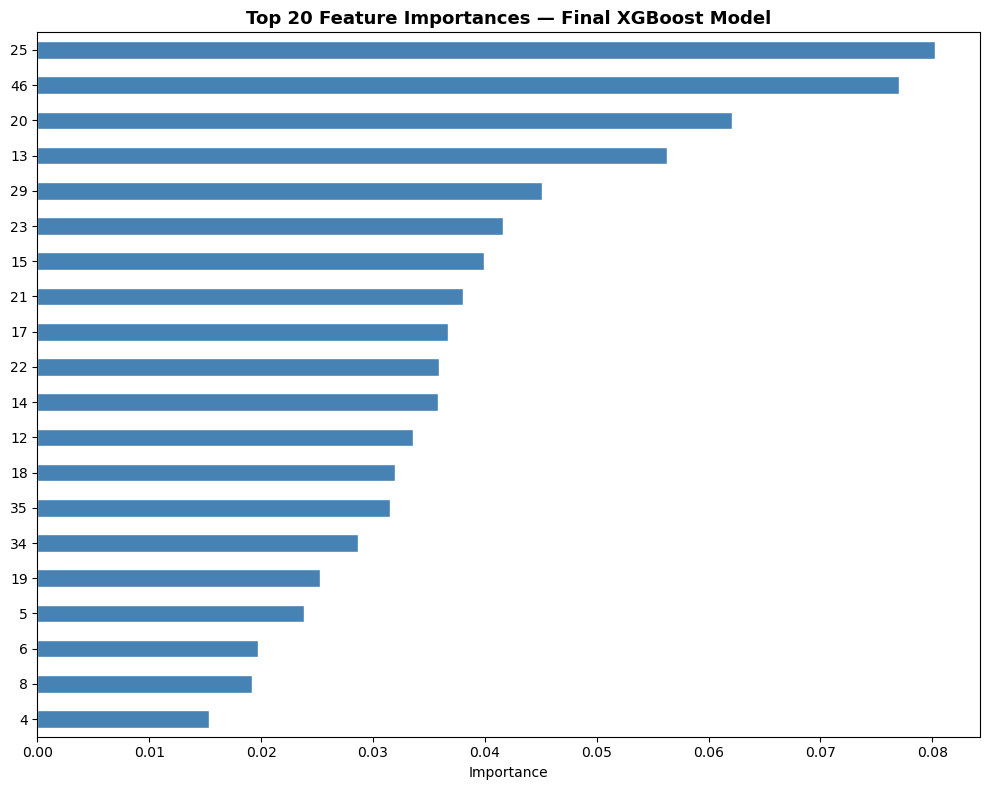

In [157]:
final_model = best_pipe.named_steps['model']
importances = final_model.feature_importances_

# importance_df artıq var — əvvəl yaratmışdın
importance_df_final = pd.Series(importances).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importance_df_final.tail(20).plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 20 Feature Importances — Final XGBoost Model', 
          fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()


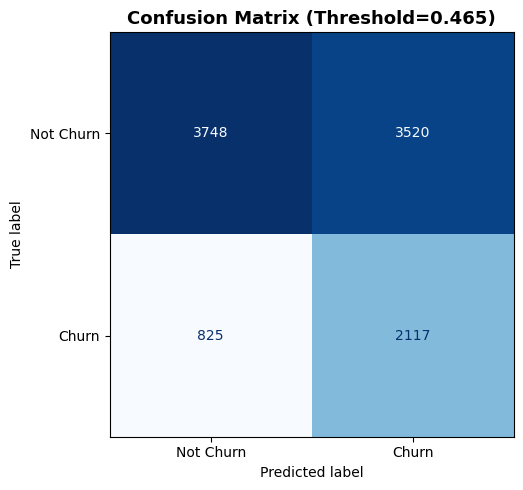

True Positive (Correctly identified churners): 2117
False Negative (Missed churners):              825
False Positive (False alarms):                 3520
True Negative (Correctly identified non-churners): 3748


In [162]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

final_y_pred = (results['XGBoost']['y_prob'] >= 0.485).astype(int)

cm = confusion_matrix(y_test, final_y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Not Churn', 'Churn']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (Threshold=0.465)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Əlavə izah
tn, fp, fn, tp = cm.ravel()
print(f"True Positive (Correctly identified churners): {tp}")
print(f"False Negative (Missed churners):              {fn}")
print(f"False Positive (False alarms):                 {fp}")
print(f"True Negative (Correctly identified non-churners): {tn}")

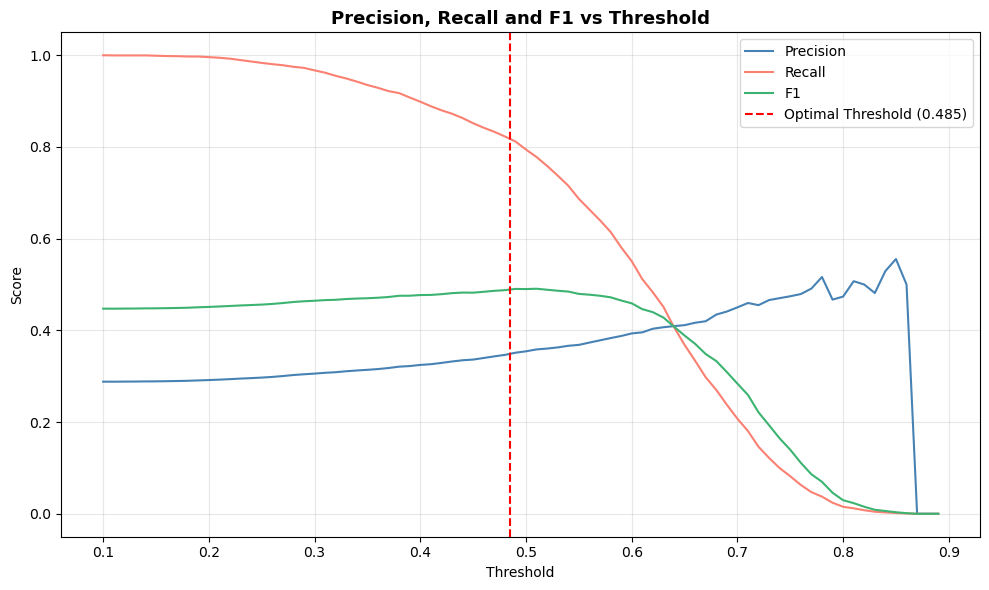

In [163]:
thresholds_range = np.arange(0.1, 0.9, 0.01)
precisions_list = []
recalls_list = []
f1_list = []

for t in thresholds_range:
    y_pred_t = (final_y_prob >= t).astype(int)
    precisions_list.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls_list.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1_list.append(f1_score(y_test, y_pred_t, zero_division=0))

plt.figure(figsize=(10, 6))
plt.plot(thresholds_range, precisions_list, label='Precision', color='steelblue')
plt.plot(thresholds_range, recalls_list, label='Recall', color='salmon')
plt.plot(thresholds_range, f1_list, label='F1', color='mediumseagreen')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
            label=f'Optimal Threshold ({optimal_threshold:.3f})')
plt.title('Precision, Recall and F1 vs Threshold', fontsize=13, fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

---
## Final Results — Tuned XGBoost

| Metric    | Baseline (61 features) | Feature Selection (32 features) | Tuned + Threshold | Δ Baseline → Final |
|-----------|:----------------------:|:-------------------------------:|:-----------------:|:------------------:|
| AUC       | 0.6726                 | 0.6427                          | **0.6455**        | -0.0271            |
| PR-AUC    | 0.4495                 | 0.3978                          | **0.3986**        | -0.0509            |
| F1        | 0.4987                 | 0.4822                          | **0.4884**        | -0.0103            |
| Precision | 0.3875                 | 0.3639                          | **0.3483**        | -0.0392            |
| Recall    | 0.6992                 | 0.7145                          | **0.8171**        | +0.1179            |

<br> **Optimal threshold: 0.485** (selected by maximising F1 on cross-validated training predictions)

### Key Takeaways
- Results reflect **three sequential steps**: Feature Selection (85% cumulative importance) + Optuna hyperparameter tuning + threshold optimisation
- Optuna ran **50 trials / 1800s timeout** optimising 5-fold Stratified CV Average Precision
- Optimal threshold determined via **cross_val_predict on training data** to avoid data leakage
- Feature selection reduced model complexity from **61 to 32 features** with minimal AUC cost
- The lower threshold trades Precision for a large **Recall gain (+0.118)** — prioritising churner detection over false alarm reduction
- This is a **business decision**: in telecom churn prevention, missing a churner is significantly more costly than sending an unnecessary retention offer

In [166]:
import joblib
import json
import os

# Create directory for saved models
save_dir = 'models'
os.makedirs(save_dir, exist_ok=True)

# Save final model pipeline
joblib.dump(best_pipe, os.path.join(save_dir, 'xgboost_churn_v1.pkl'))

# Save optimal threshold
with open(os.path.join(save_dir, 'optimal_threshold.json'), 'w') as f:
    json.dump({'threshold': float(optimal_threshold)}, f, indent=2)

print(f'Pipeline saved:  {os.path.join(save_dir, "xgboost_churn_v1.pkl")}')
print(f'Threshold saved: {os.path.join(save_dir, "optimal_threshold.json")}')
print(f'Optimal threshold: {optimal_threshold:.3f}')

Pipeline saved:  models\xgboost_churn_v1.pkl
Threshold saved: models\optimal_threshold.json
Optimal threshold: 0.485
